## YOONKYU LEE (yoonkyu2) Lab 2 Full Notebook

Difficulties / Bugs Encountered
One difficulty was managing different environments across the PC and Raspberry Pi, especially when some tools required full TensorFlow while deployment on the Pi used tflite_runtime. I also ran into camera/backend issues on the Raspberry Pi, so I separated image capture and inference into different execution flows to make the pipeline more stable.

What I Learned
Through this lab, I learned how to take a model from PyTorch training all the way to edge deployment using ONNX, TensorFlow SavedModel, TFLite, and the Coral Edge TPU. I also learned that deployment performance depends not only on model accuracy, but also on quantization, data movement overhead, batching strategy, and hardware/software compatibility.

I included extra markdown cells at the end of each part for report. Please read each of them for the rest of the requirements for the report. 

ECE479ICC LAB 2: Raspberry Pi, TF-Keras, and Face Detection
====================================


## PART I: Raspberry Pi Setup and Basics

### Raspberry Pi Setup

From this lab on, you will apply what you have learned in the lectures to train and deploy a neural network on an edge device, Raspberry Pi 5.

Raspberry Pi 5 is an inexpensive but powerful IoT device. To start, you need to install the proper operating system, you can refer to this [tutorial][headless_rpi_start]. You can use the official [imager] to prepare your OS, you should use the default 64-bit Debian Trixie. If you are at home without a monitor, you can set up the OS with the headless option. 

Once your RPi can boot into the OS normally, you can enable the VNC and access the desktop environment using your laptop/desktop. You can follow the "Enabling and Connecting over VNC" section of the [tutorial][headless_rpi_start] for this.

Now that you have the desktop environment, follow this [guide][picam_start] to set up your pi-camera. You should be able to take pictures and videos with your camera. **You have to power off the pi when you are doing installation**

[raspberry_pi_history]:https://www.techrepublic.com/article/inside-the-raspberry-pi-the-story-of-the-35-computer-that-changed-the-world/
[image_link]:https://github.com/google-coral/aiy-maker-kit-tools/releases/download/v20220518/aiy-maker-kit-2022-05-18.img.xz
[imager]:https://www.raspberrypi.com/software/
[headless_rpi_start]: https://www.tomshardware.com/reviews/raspberry-pi-headless-setup-how-to,6028.html
[rpi_headless]:https://www.raspberrypi.com/documentation/computers/configuration.html#setting-up-a-headless-raspberry-pi
[rpi_ssh]:https://www.raspberrypi.com/documentation/computers/remote-access.html
[picam_start]:https://youtu.be/3TErT4HhZXo?si=-9pjF_yjx3Ynmf_7
[headless_setup]:https://www.raspberrypi.org/documentation/remote-access/ssh/

In this part of the lab, you need to complete the following tasks: 

  * Install Raspbian OS in your Raspberry Pi, set up your network connection, and take a selfie on the pi-camera.
  * **Print** the CPU specs with `cat /proc/cpuinfo`
  * **Print** network interface configuration with `ifconfig`
  
  
### Edge TPU Setup on Raspberry Pi

This guide assumes you have a fresh Raspberry Pi OS install. We will first establish a stable Python 3.10 environment, then install the hardware drivers for the Coral Edge TPU, and finally the necessary Python libraries.

#### **Step 1: Install Python 3.10 via Pyenv**
The default system Python on newer Raspberry Pi OS versions can be restrictive. We will use **Pyenv** to create an isolated workspace with Python 3.10.

1.  **Install Build Dependencies**
    These are required to compile Python and avoid errors like "ModuleNotFoundError: _ssl".
    ```bash
    sudo apt-get update && sudo apt-get upgrade -y
    
    sudo apt-get install -y make build-essential libssl-dev zlib1g-dev \
    libbz2-dev libreadline-dev libsqlite3-dev wget curl llvm libncurses5-dev \
    libncursesw5-dev xz-utils tk-dev libffi-dev liblzma-dev python3-openssl
    ```

2.  **Install Pyenv**
    ```bash
    curl [https://pyenv.run](https://pyenv.run) | bash
    ```

3.  **Configure Shell**
    Run these commands to add Pyenv to your path (or add them to `~/.bashrc`):
    ```bash
    echo 'export PYENV_ROOT="$HOME/.pyenv"' >> ~/.bashrc
    echo '[[ -d $PYENV_ROOT/bin ]] && export PATH="$PYENV_ROOT/bin:$PATH"' >> ~/.bashrc
    echo 'eval "$(pyenv init -)"' >> ~/.bashrc
    echo 'eval "$(pyenv virtualenv-init -)"' >> ~/.bashrc
    source ~/.bashrc
    ```

4.  **Install Python 3.10.15**
    *Note: This step may take 10-15 minutes on a Raspberry Pi.*
    ```bash
    pyenv install 3.10.15
    ```

5.  **Create Virtual Environment**
    ```bash
    pyenv virtualenv 3.10.15 ECE479
    pyenv activate ECE479
    ```

---

#### **Step 2: Install Edge TPU Drivers & System Libraries**
Now that Python is ready, we install the low-level drivers for the USB Accelerator and the graphics libraries required by OpenCV.

1.  **Add Google Coral Repository**
    ```bash
    curl -fsSL [https://packages.cloud.google.com/apt/doc/apt-key.gpg](https://packages.cloud.google.com/apt/doc/apt-key.gpg) | sudo gpg --dearmor -o /usr/share/keyrings/coral-edgetpu-archive-keyring.gpg

    echo "deb [signed-by=/usr/share/keyrings/coral-edgetpu-archive-keyring.gpg] [https://packages.cloud.google.com/apt](https://packages.cloud.google.com/apt) coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list
    ```

2.  **Install Drivers**
    ```bash
    sudo apt-get update
    
    # libedgetpu1-std: The driver for the USB stick
    # libgl1/libglib: Graphics dependencies for OpenCV
    sudo apt-get install -y libedgetpu1-std libgl1 libglib2.0-0t64
    ```

---

#### **Step 3: Install Python Packages**
We must install specific versions to avoid compatibility issues between TensorFlow Lite and NumPy 2.0.

```bash
# Ensure we are in our environment
pyenv activate ECE479

# Install libraries with version pinning
pip install "numpy<2" "opencv-python<4.11" tflite-runtime
```
**Verification:** Plug in your Coral USB Accelerator and run:
    ```bash
python -c "import tflite_runtime.interpreter as tflite; print('Delegate:', tflite.load_delegate('libedgetpu.so.1'))"
    ```
If it prints a Delegate object address, you are ready.




### Prerequisites for laptop/PCs

For this part of the lab, you will perform the training and conversion on your **host computer** (laptop or desktop), not the Raspberry Pi.

To support the workflow of training in PyTorch and converting to a format compatible with the Coral Edge TPU, you need to install a specific set of libraries with **strict version compatibility**.

**Please run the following command in your terminal or a code cell to install the required packages:**

```bash
# We pin specific versions to ensure compatibility between ONNX, TensorFlow, and the Edge TPU tools.
pip install torch torchvision matplotlib onnx==1.12.0 onnx-tf tensorflow==2.15.0 tensorflow-probability==0.23.0 tensorflow-addons==0.23.0 tf-keras
```

### Option 2: Special Note for Mac / Apple Silicon Users
*You can add this block right after the prerequisites if you expect many students to use Macs. This saves them from the "CMake" and "Architecture" errors you faced.*



### Note for Mac Users

If you are using a Mac with Apple Silicon, standard pip installations for `onnx` may fail with compilation errors. It is **highly recommended** to use a Conda environment to fetch pre-built binaries.

**Recommended Setup for Mac:**
1.  Create a fresh environment with Python 3.10:
    ```bash
    conda create -n ECE479 python=3.10 -y
    conda activate ECE479
    ```
2.  Install PyTorch and ONNX from Conda-Forge (avoids compilation issues):
    ```bash
    conda install -c pytorch -c conda-forge pytorch torchvision onnx=1.12.0 -y
    ```
3.  Install the remaining tools via Pip:
    ```bash
    pip install onnx-tf tensorflow==2.15.0 tensorflow-macos==2.15.0 tensorflow-addons==0.23.0 tensorflow-probability==0.23.0 tf-keras
    ```

### Note for Windows + Python 3.12 Users

TensorFlow 2.15.0 **does not provide wheels for Python 3.12 on Windows** (only 3.9–3.11). If you see `No matching distribution found for tensorflow==2.15.0`, use a **Python 3.10** environment.

**Option A – Conda (recommended):**
```bash
conda create -n ECE479 python=3.10 -y
conda activate ECE479
pip install torch torchvision matplotlib onnx==1.12.0 onnx-tf tensorflow==2.15.0 tensorflow-probability==0.23.0 tensorflow-addons==0.23.0 tf-keras
```

**Option B – venv (if Python 3.10 is installed):**
```bash
py -3.10 -m venv .venv_ece479
.venv_ece479\\Scripts\\activate
pip install torch torchvision matplotlib onnx==1.12.0 onnx-tf tensorflow==2.15.0 tensorflow-probability==0.23.0 tensorflow-addons==0.23.0 tf-keras
```
Then in VS Code/Cursor: select the kernel for `.venv_ece479` or `ECE479` (conda).

## REPORT PART I: Raspberry Pi Setup and Basics

1. The CPU Spec:

```text
(ECE479_coral) yoonkyu2@ykspi:~/ece479 $ cat /proc/cpuinfo
processor       : 0
BogoMIPS        : 108.00
Features        : fp asimd evtstrm aes pmull sha1 sha2 crc32 atomics fphp asimdhp cpuid asimdrdm lrcpc dcpop asimddp
CPU implementer : 0x41
CPU architecture: 8
CPU variant     : 0x4
CPU part        : 0xd0b
CPU revision    : 1

processor       : 1
BogoMIPS        : 108.00
Features        : fp asimd evtstrm aes pmull sha1 sha2 crc32 atomics fphp asimdhp cpuid asimdrdm lrcpc dcpop asimddp
CPU implementer : 0x41
CPU architecture: 8
CPU variant     : 0x4
CPU part        : 0xd0b
CPU revision    : 1

processor       : 2
BogoMIPS        : 108.00
Features        : fp asimd evtstrm aes pmull sha1 sha2 crc32 atomics fphp asimdhp cpuid asimdrdm lrcpc dcpop asimddp
CPU implementer : 0x41
CPU architecture: 8
CPU variant     : 0x4
CPU part        : 0xd0b
CPU revision    : 1

processor       : 3
BogoMIPS        : 108.00
Features        : fp asimd evtstrm aes pmull sha1 sha2 crc32 atomics fphp asimdhp cpuid asimdrdm lrcpc dcpop asimddp
CPU implementer : 0x41
CPU architecture: 8
CPU variant     : 0x4
CPU part        : 0xd0b
CPU revision    : 1

Revision        : e04171
Serial          : 989900553d497a88
Model           : Raspberry Pi 5 Model B Rev 1.1
```

2. The network configuration:

```text
(ECE479_coral) yoonkyu2@ykspi:~/ece479 $ ifconfig
eth0: flags=4099<UP,BROADCAST,MULTICAST>  mtu 1500
        ether 88:a2:9e:3b:94:58  txqueuelen 1000  (Ethernet)
        RX packets 0  bytes 0 (0.0 B)
        RX errors 0  dropped 0  overruns 0  frame 0
        TX packets 0  bytes 0 (0.0 B)
        TX errors 0  dropped 0 overruns 0  carrier 0  collisions 0
        device interrupt 106

lo: flags=73<UP,LOOPBACK,RUNNING>  mtu 65536
        inet 127.0.0.1  netmask 255.0.0.0
        inet6 ::1  prefixlen 128  scopeid 0x10<host>
        loop  txqueuelen 1000  (Local Loopback)
        RX packets 20786  bytes 140555982 (134.0 MiB)
        RX errors 0  dropped 0  overruns 0  frame 0
        TX packets 20786  bytes 140555982 (134.0 MiB)
        TX errors 0  dropped 0 overruns 0  carrier 0  collisions 0

wlan0: flags=4163<UP,BROADCAST,RUNNING,MULTICAST>  mtu 1500
        inet 192.168.1.16  netmask 255.255.255.0  broadcast 192.168.1.255
        inet6 fe80::8aa2:9eff:fe3b:9459  prefixlen 64  scopeid 0x20<link>
        ether 88:a2:9e:3b:94:59  txqueuelen 1000  (Ethernet)
        RX packets 322181  bytes 460898842 (439.5 MiB)
        RX errors 0  dropped 0  overruns 0  frame 0
        TX packets 69262  bytes 16706863 (15.9 MiB)
        TX errors 0  dropped 0 overruns 0  carrier 0  collisions 0
```

3. The TensorFlow checks (version, GPU, etc.)

in my Windows PC where the ipynb notebook is ran:


In [9]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Physical devices:", tf.config.list_physical_devices())
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
Built with CUDA: False
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU devices: []


In the Raspberry Pi 5:

```text
(ECE479) yoonkyu2@ykspi:~/ece479 $ python -c "import tflite_runtime.interpreter as tflite; print('tflite_runtime imported successfully')"
tflite_runtime imported successfully
```

## PART II: Building and Training with PyTorch

In part II, you will build a Convolutional Neural Network (CNN) based image classifier. In our lecture, we have introduced CNN, a type of Deep Neural Network (DNN) that features convolutional layers. This [document][cnn_definition] by Stanford CS231n is also a good resource to learn more about CNN. You will build and train a simple CNN with PyTorch on your own computers.

[cnn_definition]:http://cs231n.github.io/convolutional-networks/

PyTorch is a flexible deep learning framework that allows for dynamic computational graphs. Unlike high-level wrappers that hide details, PyTorch gives you granular control over the forward pass of your network and the training loop. This is excellent for learning exactly how data flows through a neural network and how gradients are calculated.

In this part of the lab, you need to build a neural network to classify the Fashion MNIST dataset using torch and torchvision.

### FashionNet

You will construct a neural network by yourselves. Let's call it the FashionNet. Here is an overview of the proposed Convolutional Neural Network (CNN):

![cnn_img](figures/fashionnet.png)

This CNN contains two convolutional layers, two max pooling layers, and three fully connected layers (dense layers). The configuration details of each layer are shown in the following table (in sequential order):

| Layers          | Configuration                        | Activation | Output Dimensions |
|---------------:|--------------------------------------:|-------------------:|----------------------------------------: |
| convolution     | input channels=1, output channels=4, kernel=5x5, stride=1, padding=2 (same)   |       ReLU          |            (28, 28, 4)                     |
| max pooling     | kernel=2x2, stride=2                           |       -             |            (14, 14, 4)                     |
| convolution     | input channels=4, output channels=8, kernel=3x3, stride=1, padding=0 (valid)|       ReLU          |            (12, 12, 8)                     |
| max pooling     | kernel=2x2, stride=2                           |       -             |            (6, 6, 8)                       |
| dense | input features=288 (6\*6\*8), output=128      |       ReLU          |            (128)                     |
| dense | input=128, output=64       |       ReLU          |            (64)                      |
| dense | input=64, output=10        |       - (Logits)* |            (10)                      |

*\*Note: In PyTorch, when using `CrossEntropyLoss`, the last layer typically outputs raw logits rather than applying Softmax directly.*

### Dataset
In this lab, you will use the Fashion MNIST dataset provided by `torchvision`. You will use a `DataLoader` to handle batching and shuffling:

```python
import torch
import torchvision
import torchvision.transforms as transforms

# Transform to Tensor (scales data to [0,1])
transform = transforms.Compose([transforms.ToTensor()])

train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Define DataLoaders
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)
```
As discussed in the lecture, you should use the training set to train your model. You may also want to validate your model by splitting the `train_set` further into training and validation subsets using `torch.utils.data.random_split`.

### Build, Train, and Evaluate
Generally, there are three stages in the process of developing a neural network: build, train, and evaluate. In PyTorch, these steps are explicit and give you full control over the process:

1. **Build**: First, you define the model architecture. In PyTorch, you define a class that inherits from `nn.Module`. You specify your layers in `__init__` and the data flow in `forward`. You can find the documentation for convolution layers [here][conv_doc] and linear layers [here][linear_doc].
2. **Train**: You define a loss function (e.g., `CrossEntropyLoss`) and an optimizer (e.g., `Adam` or `SGD`). Unlike high-level frameworks, you will write a **training loop** that iterates over your `DataLoader`. In this loop, you perform the forward pass, calculate loss, perform backpropagation (`loss.backward()`), and update weights (`optimizer.step()`).
3. **Evaluate**: After training (or during validation), you test the final accuracy. You should switch your model to evaluation mode using `model.eval()` and use the `torch.no_grad()` context manager to disable gradient calculation, which saves memory and computation.

The training of this CNN should not take a very long time on a laptop/desktop CPU. The final testing accuracy should be higher than **85%**, and the training accuracy should be higher than **90%**.

### Plot the Training Progress
Since you are writing a custom training loop, `torch` does not automatically store history like Keras does. You must manually track the metrics.

**Create lists (e.g., `train_losses`, `val_accuracies`) in your code and append the calculated loss/accuracy values at the end of every epoch.**

**Use `matplotlib` to graph the model accuracy and loss on the training and validation dataset, and include them in your report.** The graph should look something like the following, but yours can be different if you have different configurations of the training process.

![train_img](figures/train_2.png)

### Saving Your Trained Model
Finally, you will need to save your trained models. Saving a trained model allows you to deploy it to other devices or restore previous training progress at a later time.

For this lab, specifically to support the subsequent deployment to the **Coral Edge TPU**, you must save the model in two ways:

1. **PyTorch State Dict**: Save the standard PyTorch weights for future use or retraining.
2. **ONNX Export**: To deploy on the Edge TPU, we must eventually convert the model to TensorFlow Lite. The bridge between PyTorch and TFLite is the **ONNX** (Open Neural Network Exchange) format.

```python
# 1. Save standard PyTorch weights
torch.save(model.state_dict(), "fashion_net.pth")

# 2. Export to ONNX for deployment
dummy_input = torch.randn(1, 1, 28, 28) # Dummy input to trace the graph
torch.onnx.export(model, dummy_input, "model_1x1.onnx", input_names=['input'], output_names=['output'])
```


The overall conversion flow should look like

![conversion](figures/conversion_flow.png)

In [11]:
# Environment Check: PyTorch / torchvision / matplotlib / notebook kernel
import torch
print(torch.__version__)
import torchvision
print(torchvision.__version__)
import matplotlib.pyplot as plt
print("matplotlib ok")
import sys

2.11.0+cpu
0.26.0+cpu
matplotlib ok


In [12]:
# Baseline (Single Image 28x28) - Step 1: Import libraries
# Step 1: Import libraries

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [13]:
# Baseline (Single Image 28x28) - Step 2: Load dataset and create DataLoaders
# Transform to Tensor (scales data to [0,1])
transform = transforms.Compose([transforms.ToTensor()])

train_set = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

test_set = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(f"Training samples: {len(train_set)}")
print(f"Test samples: {len(test_set)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Training samples: 60000
Test samples: 10000
Number of training batches: 938
Number of test batches: 157


In [14]:
# Baseline (Single Image 28x28) - Step 3: Define the FashionNet model

class FashionNet(nn.Module):
    def __init__(self):
        super(FashionNet, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=4, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6 * 6 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = FashionNet()
print(model)

FashionNet(
  (features): Sequential(
    (0): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=288, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [15]:
# Baseline (Single Image 28x28) - Step 4: Set up training components

# Use GPU if available; otherwise fall back to CPU. 
# (I tried to utilize my rtx4080 but I couldn't figure out...)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the model and move it to the selected device for training
model = FashionNet().to(device)

# CrossEntropyLoss expects raw logits from the final layer
criterion = nn.CrossEntropyLoss()

# Chose Adam as optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 10 epochs
num_epochs = 10

# Store metrics...
train_losses = []
train_accuracies = []
test_accuracies = []

print("Using device:", device)

Using device: cpu


In [16]:
# Baseline (Single Image 28x28) - Step 5: Define training and evaluation functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Clear old gradients before the new backward pass.
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Disable gradient tracking during evaluation.
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = running_loss / total
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy


In [17]:

# Baseline (Single Image 28x28) - Step 6: Train the model and record metrics

# Initialize because I'm trial-and-error-ing on this cell 
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Test Loss: {test_loss:.4f} "
        f"| Train Acc: {train_acc:.2f}% "
        f"| Test Acc: {test_acc:.2f}%"
    )


Epoch [1/10] | Train Loss: 0.7043 | Test Loss: 0.5266 | Train Acc: 73.44% | Test Acc: 79.80%
Epoch [2/10] | Train Loss: 0.4593 | Test Loss: 0.4515 | Train Acc: 83.20% | Test Acc: 83.56%
Epoch [3/10] | Train Loss: 0.3955 | Test Loss: 0.4079 | Train Acc: 85.58% | Test Acc: 85.59%
Epoch [4/10] | Train Loss: 0.3604 | Test Loss: 0.3644 | Train Acc: 86.77% | Test Acc: 86.88%
Epoch [5/10] | Train Loss: 0.3341 | Test Loss: 0.3486 | Train Acc: 87.59% | Test Acc: 87.54%
Epoch [6/10] | Train Loss: 0.3145 | Test Loss: 0.3356 | Train Acc: 88.38% | Test Acc: 87.88%
Epoch [7/10] | Train Loss: 0.2972 | Test Loss: 0.3370 | Train Acc: 89.06% | Test Acc: 88.01%
Epoch [8/10] | Train Loss: 0.2858 | Test Loss: 0.3168 | Train Acc: 89.28% | Test Acc: 88.64%
Epoch [9/10] | Train Loss: 0.2730 | Test Loss: 0.3197 | Train Acc: 89.82% | Test Acc: 88.61%
Epoch [10/10] | Train Loss: 0.2599 | Test Loss: 0.3254 | Train Acc: 90.36% | Test Acc: 88.44%


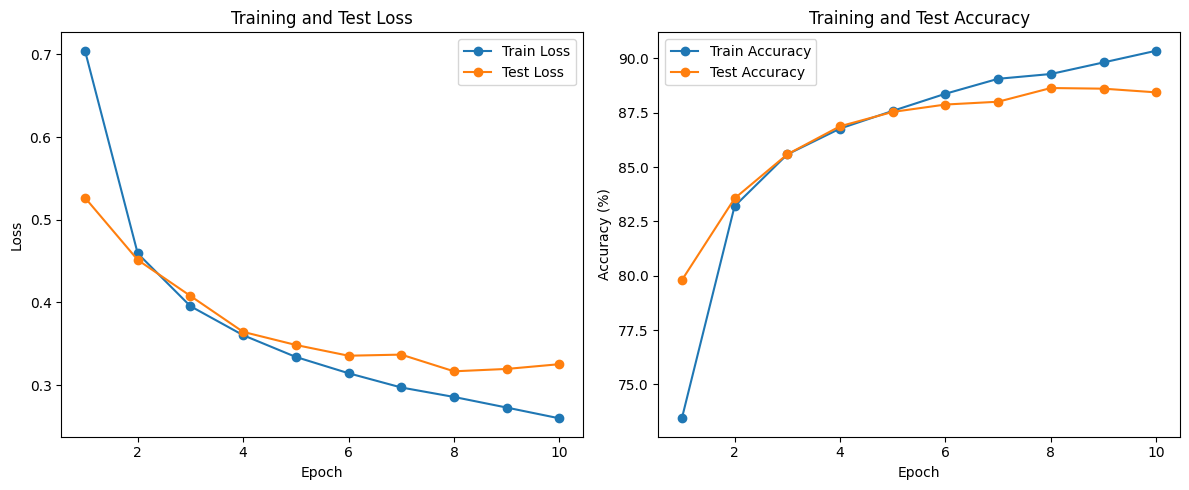

Final Test Accuracy: 88.44%
Saved PyTorch model to model_1x1.pth


In [18]:
# Baseline (Single Image 28x28) - Step 7: Plot training results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, num_epochs + 1), test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, marker="o", label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Test Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


final_test_loss, final_test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

torch.save(model.state_dict(), "model_1x1.pth")
print("Saved PyTorch model to model_1x1.pth")


In [25]:
# Baseline (Single Image 28x28) - Step 8: Save the model and export to ONNX

model_cpu = model.to("cpu")
model_cpu.eval()

dummy_input = torch.randn(1, 1, 28, 28)

torch.onnx.export(
    model_cpu,
    dummy_input,
    "model_1x1.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11,
    dynamo=False
)

print("Exported ONNX model to model_1x1.onnx")


Exported ONNX model to model_1x1.onnx


C:\Users\yoong\AppData\Local\Temp\ipykernel_33560\1954624945.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


### Convert Your Trained Model to TFLite model

Before you start the migration process of your trained model onto our edge devices (Raspberry Pi 4), please make sure you have followed the previous steps carefully. You should have a trained PyTorch model with reasonable accuracy and, crucially, you must have **exported it to ONNX format** (`model_1x1.onnx`) as described in the previous section.

Since the TFLite Converter does not natively support PyTorch or ONNX files, we must first convert the ONNX model into a TensorFlow SavedModel. Once that is done, we can create the TFLite converter.

1.  **Convert ONNX to TensorFlow**: Use the `onnx-tf` library to generate a TensorFlow SavedModel folder from your ONNX file.
2.  **Create Converter**: Load the resulting TensorFlow model into `TFLiteConverter`.

```python
import onnx
from onnx_tf.backend import prepare
import tensorflow as tf

# 1. Convert ONNX to TF SavedModel
# Load the ONNX file
onnx_model = onnx.load("model_1x1.onnx")
# Prepare the Tensorflow representation
tf_rep = prepare(onnx_model)
# Export to a TF SavedModel folder (this creates a folder named 'model_1x1_tf')
tf_rep.export_graph("model_1x1_tf")

# 2. Create TFLite Converter
# Now we can load the TF model just like a standard TensorFlow workflow
converter = tf.lite.TFLiteConverter.from_saved_model("model_1x1_tf")
```

Please refer to [this document][tf_lite_converter] for more information on the TFLite model.

[tf_lite_converter]:https://www.tensorflow.org/lite/api_docs/python/tf/lite/TFLiteConverter#from_saved_model

In [21]:
# Baseline Conversion - Environment check for TensorFlow / ONNX / onnx-tf
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import onnx
from onnx_tf.backend import prepare
import tensorflow as tf
import numpy as np

# Verify it works now
print("TF Version:", tf.__version__)
try:
    print("Keras Version:", tf.keras.__version__)
except:
    print("Keras loaded successfully (version attribute hidden)")

TF Version: 2.15.0
Keras loaded successfully (version attribute hidden)


In [24]:
# Baseline Conversion - Step 9: Convert ONNX model to TensorFlow SavedModel

import onnx
from onnx_tf.backend import prepare

onnx_model = onnx.load("model_1x1.onnx")
tf_rep = prepare(onnx_model)
tf_rep.export_graph("model_1x1_tf")

print("Exported TensorFlow SavedModel to model_1x1_tf")


INFO:absl:Function `__call__` contains input name(s) x with unsupported characters which will be renamed to transpose_12_x in the SavedModel.
INFO:absl:Found untraced functions such as gen_tensor_dict while saving (showing 1 of 1). These functions will not be directly callable after loading.


INFO:tensorflow:Assets written to: model_1x1_tf\assets


INFO:tensorflow:Assets written to: model_1x1_tf\assets
INFO:absl:Writing fingerprint to model_1x1_tf\fingerprint.pb


Exported TensorFlow SavedModel to model_1x1_tf


### Optimize your TFLite model with post-training quantization

With the converter, we can directly transform our model to a TFLite model; however, edge and IoT devices are usually low-powered and lack computational power compared to a PC. Therefore, to further enhance performance, you can apply post-training quantization techniques before deploying the model onto the Raspberry Pi.

Although post-training quantization is similar to the quantization-aware training technique (introduced in Lecture 12), the model is not retrained after quantization, so the impact on accuracy can be larger.

In this part, you will apply two quantization methods: **Dynamic range quantization** and **Full integer quantization** (required for the Edge TPU). You will then compare their accuracy and performance.

1.  **Dynamic Range Quantization:**
    Quantization parameters are automatically detected and generated by TensorFlow. Write a piece of code to convert your `model_1x1_tf` model into a TFLite model using dynamic range quantization. This is achieved by enabling default optimizations without specifying a target type.

2.  **Full Integer Quantization:**
    For integer quantization, the converter needs to sample the dataset to estimate the **MIN** and **MAX** values of activations. This process is called "representative data generation".

    Since our original data is in PyTorch, we can define a generator that pulls images directly from our existing `test_loader`:

    ```python
    def representative_data_gen():
        # We sample 100 images for calibration
        steps = 100
        count = 0
        for images, _ in test_loader:
            for i in range(images.size(0)):
                if count >= steps:
                    return
                # Get single image and convert to numpy for TFLite
                img_np = images[i].unsqueeze(0).numpy()
                yield [img_np]
                count += 1
    ```

    You will need to use this function when configuring the `TFLiteConverter`. Remember to enforce full integer quantization by setting the `inference_input_type` and `inference_output_type` to `tf.int8`, which is mandatory for the Coral Edge TPU.

[post-trainning quantization]:https://www.tensorflow.org/lite/performance/post_training_quantization

In [26]:
# Baseline Conversion - Step 11: Full Integer Quantization to TFLite
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model("model_1x1_tf")

# Enable default optimization for dynamic range quantization.
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model_dynamic = converter.convert()

with open("model_1x1_dynamic.tflite", "wb") as f:
    f.write(tflite_model_dynamic)

print("Saved dynamic range quantized model to model_1x1_dynamic.tflite")


Saved dynamic range quantized model to model_1x1_dynamic.tflite


In [27]:
# Implement Full Integer Quantization for converting into tflite

import tensorflow as tf

def representative_data_gen():
    steps = 100
    count = 0
    
    for images, _ in test_loader:
        for i in range(images.size(0)):
            if count >= steps:
                return
            img_np = images[i].unsqueeze(0).numpy()
            yield [img_np]
            count += 1

converter = tf.lite.TFLiteConverter.from_saved_model("model_1x1_tf")

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Force full integer quantization for Edge TPU compatibility.
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_fullint = converter.convert()

with open("model_1x1_fullint.tflite", "wb") as f:
    f.write(tflite_model_fullint)

print("Saved full integer quantized model to model_1x1_fullint.tflite")



Saved full integer quantized model to model_1x1_fullint.tflite


### Save and deploy your TFLite model
Save your converted TFLite models as binary files. Example code:
```Python
# Save the model.
with open('model.tflite', 'wb') as f:
  f.write(tflite_model)
```

To run execute the TFLite model on the RPi, you can refer to [this example][TFLite] for the details. In general, the following code is the standard process.
#### Step 1: load the model and allocate the tensors
We first need to instantiate the model with the TFLite model file, and then allocate all the tensors.
```Python
# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()
```
#### Step 2: Check input and output info
To get the input and output tensor's names and their corresponding sizes, we will first need do the following steps to extract these information.
```Python
# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
```
#### Step 3: Set input tensor and run the model
Once we got the input tensor's name and shape, we can then set the input tensor and run the model.
```Python
# Test the model on random input data.
input_shape = input_details[0]['shape']
interpreter.set_tensor(input_details[0]['index'], input_data)

# Run the model
interpreter.invoke()
```
#### Step 4: Extract the output tensor
We can finally run the `get_tensor(...)` function again to extract the output.
```Python
# The function `get_tensor()` returns a copy of the tensor data.
# Use `tensor()` in order to get a pointer to the tensor.
output_data = interpreter.get_tensor(output_details[0]['index'])
print(output_data)
```
Follow [tutorial][TPU] to run your converted TFLite model on your Raspberry Pi with the Edge TPU.

**Please convert your model with these two different methods and report their corresponding accuracy and inference time with the TFLite model on the RPi with and without the Edge TPU. Compare and comment on what you observed in the report.**
##### **1. Model Conversion**
You must prepare two versions of your model to compare performance:
* **Model A (CPU):** Your standard Quantized TFLite model.
* **Model B (Edge TPU):** A compiled version of Model A, optimized for the accelerator.

##### **2. Compiling for Edge TPU**
** IMPORTANT:** The Edge TPU Compiler **cannot** be installed on the Raspberry Pi.
You must perform this step on a **x86-64 machine**.

Follow the [official guide](https://coral.ai/docs/edgetpu/compiler#system-requirements) to install the compiler, then run:
```bash
edgetpu_compiler -s facenet_fullint.tflite
```
Transfer the resulting `_edgetpu.tflite file` to your Raspberry Pi.

##### **3. Benchmarking Task**
Test your model on the Raspberry Pi in two modes:

CPU Mode: Load the standard `.tflite` model (disable the delegate).

TPU Mode: Load the `_edgetpu.tflite` model with libedgetpu.so.1.

[install]:https://coral.ai/docs/accelerator/get-started/#1-install-the-edge-tpu-runtime
[TFLite]:https://www.tensorflow.org/lite/guide/inference#load_and_run_a_model_in_python
[TPU]:https://coral.ai/docs/accelerator/get-started/#3-run-a-model-on-the-edge-tpu


#### Step 5: Experiment with Spatial Batching (Advanced Optimization)

The Edge TPU is extremely fast at computing (often < 0.1 ms for small models), but the data transfer over USB can be a bottleneck (often ~2.0 ms per transaction). This means that for very small inputs like a single FashionMNIST image ($28 \times 28$), the accelerator spends most of its time **waiting for data** rather than computing.

To overcome this "USB Tax," you will implement **Spatial Batching**. Instead of sending images one by one, you will stitch multiple images together into a single larger input grid and process them in one pass.



**Your Task:**
1.  **Update Data Loading:** Write a script to stitch your test images into two new configurations:
    * **4-Image Batch:** Stitch 4 images ($2 \times 2$ grid) into a single $56 \times 56$ input.
    * **16-Image Batch:** Stitch 16 images ($4 \times 4$ grid) into a single $112 \times 112$ input.
2.  **Update Model Architecture:** Modify your model to accept these larger input sizes.
    * *Hint:* You will need to adjust your Convolutional layers or Pooling layers to ensure the output feature map maintains the grid structure (e.g., ensuring the final output is a $4 \times 4$ grid of predictions for the 16-image batch).
3.  **Retrain & Deploy:** Retrain these new models, convert them to TFLite (ensure full integer quantization), and compile them for the Edge TPU.
4.  **Benchmark:** Run inference on the Raspberry Pi for both the **4x** and **16x** configurations.

**Deliverables:**
Report the **Accuracy**, **Total Latency (per batch)**, and **Effective Latency (per image)** in a table like the one below. Compare these results with your single-image baseline from Step 4.

| Configuration | Hardware | Accuracy | Total Batch Latency (ms) | Effective Latency per Image (ms) | Speedup Factor |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Single (1x)** | Edge TPU | ... | ... | ... | 1.0x (Baseline) |
| **Grid (4x)** | Edge TPU | ... | ... | ... | ... |
| **Grid (16x)** | Edge TPU | ... | ... | ... | ... |

**Discussion Questions:**
* How does the *Effective Latency per Image* change as you increase the batch size?
* Why does the Total Batch Latency not increase linearly (i.e., why is processing 16 images not 16x slower than processing 1 image)?
* What does this tell you about the relationship between **Compute constraints** (processing speed) and **I/O constraints** (USB bandwidth) on embedded systems?

In [44]:
# 4-Image Batch (2x2) - Step 1: Define the 4-in-1 model
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time

# ==========================================
# 1. DEFINE THE 4-IN-1 MODEL
# ==========================================
class SpatialBatchModel(nn.Module):
    def __init__(self):
        super(SpatialBatchModel, self).__init__()
        
        # Input is now 56x56 (2x2 grid of 28x28 images)
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 56 -> 28
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 28 -> 14
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)    # 14 -> 7
        )
        
        self.flatten = nn.Flatten()
        
        # Output: 40 units (4 heads * 10 classes)
        self.classifier = nn.Linear(128 * 7 * 7, 40)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        # Reshape to (Batch, 4, 10) so we have 4 distinct predictions per stitched image
        return x.view(-1, 4, 10)


In [45]:
# 4-Image Batch (2x2) - Sanity check. Verifying output shape...
model = SpatialBatchModel()
x = torch.randn(2, 1, 56, 56)
y = model(x)
print(y.shape)

torch.Size([2, 4, 10])


In [46]:
# 4-Image Batch (2x2) - Step 2: Stitch 4 images into one 56x56 input
# 2. HELPER: STITCH BATCH
# ==========================================
def stitch_batch(images, labels):
    """
    Takes a batch of N images (e.g., 128) and groups them into chunks of 4.
    Stitches them into a 2x2 grid. Returns N/4 images (e.g., 32).
    """
    batch_size = images.size(0)
    limit = (batch_size // 4) * 4
    
    stitched_images = []
    stitched_labels = []
    
    for i in range(0, limit, 4):
        img1, img2, img3, img4 = images[i:i+4]
        lbl1, lbl2, lbl3, lbl4 = labels[i:i+4]
        
        # Concatenate two images horizontally for the top row and bottom row.
        top_row = torch.cat([img1, img2], dim=2)
        bottom_row = torch.cat([img3, img4], dim=2)
        
        # Concatenate the two rows vertically to form a 2x2 grid.
        stitched = torch.cat([top_row, bottom_row], dim=1)
        
        stitched_images.append(stitched)
        stitched_labels.append(torch.tensor([lbl1, lbl2, lbl3, lbl4]))
    
    stitched_images = torch.stack(stitched_images)
    stitched_labels = torch.stack(stitched_labels)
    
    return stitched_images, stitched_labels


In [47]:
# 4-Image Batch (2x2) - Sanity check: Verify stitched image and label shapes
images, labels = next(iter(train_loader))
stitched_images, stitched_labels = stitch_batch(images, labels)

print("Original batch shape:", images.shape)
print("Stitched batch shape:", stitched_images.shape)
print("Stitched labels shape:", stitched_labels.shape)


Original batch shape: torch.Size([64, 1, 28, 28])
Stitched batch shape: torch.Size([16, 1, 56, 56])
Stitched labels shape: torch.Size([16, 4])


In [48]:
# 4-Image Batch (2x2) - Step 3: Define training and evaluation functions
# 3. TRAIN & EVAL FUNCTIONS
# ==========================================
def run_epoch(loader, is_training=True):
    if is_training:
        model.train()
    else:
        model.eval()
    
    total_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    
    for images, labels in loader:
        stitched_images, stitched_labels = stitch_batch(images, labels)
        
        stitched_images = stitched_images.to(device)
        stitched_labels = stitched_labels.to(device)
        
        if is_training:
            optimizer.zero_grad()
        
        # Enable gradients only during training.
        with torch.set_grad_enabled(is_training):
            outputs = model(stitched_images)   # [B, 4, 10]
            
            # Flatten predictions and labels so CrossEntropyLoss can be applied.
            outputs = outputs.view(-1, 10)     # [B*4, 10]
            targets = stitched_labels.view(-1) # [B*4]
            
            loss = criterion(outputs, targets)
            
            if is_training:
                loss.backward()
                optimizer.step()
        
        total_loss += loss.item() * targets.size(0)
        
        predictions = outputs.argmax(dim=1)
        correct += (predictions == targets).sum().item()
        total += targets.size(0)
    
    elapsed_time = time.time() - start_time
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy, elapsed_time


In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time

    
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

# Use GPU if available; otherwise train on CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize
model = SpatialBatchModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(f"Training Spatial Model (2x2)on {len(train_set)} images...")
print("-" * 80)
print(f"{'Epoch':<6} | {'Train Loss':<12} | {'Test Loss':<12} | {'Train Acc':<12} | {'Test Acc':<12} | {'Time':<8}")
print("-" * 80)

num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc, elapsed = run_epoch(train_loader, is_training=True)
    test_loss, test_acc, _ = run_epoch(test_loader, is_training=False)
    
    print(f"{epoch + 1:<6} | {train_loss:<12.4f} | {test_loss:<12.4f} | {train_acc:<12.2f} | {test_acc:<12.2f} | {elapsed:<8.2f}")

print("-" * 80)
print("Training Complete.")

# Save & Export
torch.save(model.state_dict(), "model_2x2.pth")

model_cpu = model.to("cpu")
model_cpu.eval()

dummy_input = torch.randn(1, 1, 56, 56)

torch.onnx.export(
    model_cpu,
    dummy_input,
    "model_2x2.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11,
    dynamo=False
)

print("\nModel saved to 'model_2x2.pth'")
print("ONNX exported to 'model_2x2.onnx'")
print("Next Step: Run the TFLite Converter script on the ONNX file.")


Training Spatial Model (2x2)on 60000 images...
--------------------------------------------------------------------------------
Epoch  | Train Loss   | Test Loss    | Train Acc    | Test Acc     | Time    
--------------------------------------------------------------------------------
1      | 0.7902       | 0.5308       | 70.59        | 80.22        | 18.87   
2      | 0.4482       | 0.4098       | 83.61        | 84.78        | 21.07   
3      | 0.3744       | 0.3904       | 86.33        | 85.33        | 22.23   
4      | 0.3394       | 0.3502       | 87.69        | 86.97        | 21.41   
5      | 0.3148       | 0.3331       | 88.44        | 87.78        | 21.42   
6      | 0.2996       | 0.3132       | 89.10        | 88.69        | 21.38   
7      | 0.2822       | 0.3008       | 89.72        | 89.29        | 21.94   
8      | 0.2691       | 0.2911       | 90.23        | 89.33        | 25.25   
9      | 0.2549       | 0.2964       | 90.60        | 89.04        | 21.30   
10     | 0.

C:\Users\yoong\AppData\Local\Temp\ipykernel_33560\1540563982.py:44: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [50]:
# 4-Image Batch (2x2) - Step 5: Convert ONNX model to TensorFlow SavedModel

import onnx
from onnx_tf.backend import prepare

onnx_model = onnx.load("model_2x2.onnx")
tf_rep = prepare(onnx_model)
tf_rep.export_graph("model_2x2_tf")

print("Exported TensorFlow SavedModel to model_2x2_tf")


INFO:absl:Function `__call__` contains input name(s) x with unsupported characters which will be renamed to transpose_15_x in the SavedModel.
INFO:absl:Found untraced functions such as gen_tensor_dict while saving (showing 1 of 1). These functions will not be directly callable after loading.


INFO:tensorflow:Assets written to: model_2x2_tf\assets


INFO:tensorflow:Assets written to: model_2x2_tf\assets
INFO:absl:Writing fingerprint to model_2x2_tf\fingerprint.pb


Exported TensorFlow SavedModel to model_2x2_tf


In [51]:
# 4-Image Batch (2x2) - Step 6: Full Integer Quantization to TFLite

import tensorflow as tf
import numpy as np
# ==========================================
# CONFIGURATION
# ==========================================
SAVED_MODEL_DIR = "model_2x2_tf"  # The folder produced by onnx-tf
TFLITE_FILE = "model_2x2_fullint.tflite"

print(f"Loading SavedModel from '{SAVED_MODEL_DIR}'...")

# 1. Define Representative Dataset (CORRECTED SHAPE)
def representative_data_gen():
    for images, labels in test_loader:
        stitched_images, _ = stitch_batch(images, labels)
        
        for i in range(stitched_images.size(0)):
            img_np = stitched_images[i].unsqueeze(0).numpy().astype(np.float32)
            yield [img_np]

# 2. Setup Converter
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)

# 3. Apply Optimizations & Quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# 4. Enforce Full Integer Quantization (Required for Edge TPU)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 5. Convert and Save
print("Converting model (this may take a minute)...")
try:
    tflite_model = converter.convert()
    
    with open(TFLITE_FILE, "wb") as f:
        f.write(tflite_model)
        
    print(f"Success! Saved '{TFLITE_FILE}'")
    print("Next Step: Run 'edgetpu_compiler -s model_2x2_fullint.tflite'")

except Exception as e:
    print(f"\nConversion Failed: {e}")
    print("Double check that 'model_2x2_tf' exists and was exported correctly from onnx-tf.")


Loading SavedModel from 'model_2x2_tf'...
Converting model (this may take a minute)...
Success! Saved 'model_2x2_fullint.tflite'
Next Step: Run 'edgetpu_compiler -s model_2x2_fullint.tflite'


In [52]:
# 16-Image Batch (4x4) - training / saving / ONNX export skeleton
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import os
import time

class SpatialSafeModel16(nn.Module):
    def __init__(self):
        super(SpatialSafeModel16, self).__init__()
        
        # We use padding=0 everywhere to prevent "Pad" ops in TFLite.
        # We use stride=2 to downsample while preserving a simple ONNX/TFLite graph.
        # Input: 112x112
        self.features = nn.Sequential(
            # Layer 1: 112 -> 55
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=0),
            nn.ReLU(),
            
            # Layer 2: 55 -> 27
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=0),
            nn.ReLU(),
            
            # Layer 3: 27 -> 13
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=0),
            nn.ReLU(),
            
            # Layer 4: 13 -> 6
            nn.Conv2d(128, 192, kernel_size=3, stride=2, padding=0),
            nn.ReLU(),
            
            # Layer 5: 6 -> 4 (Final crop to match 4x4 grid)
            nn.Conv2d(192, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU()
        )
        
        # Classifier: 1x1 Conv
        self.classifier = nn.Conv2d(256, 10, kernel_size=1)

    def forward(self, x):
        x = self.features(x)         # [Batch, 256, 4, 4]
        x = self.classifier(x)       # [Batch, 10, 4, 4]
        
        # Permute for output
        x = x.permute(0, 2, 3, 1)    # [Batch, 4, 4, 10]
        return x.reshape(-1, 16, 10) # [Batch, 16, 10]

# ==========================================
# 2. STITCHING LOGIC
# ==========================================
def stitch_batch_16(images, labels):
    batch_size = images.size(0)
    limit = (batch_size // 16) * 16
    
    stitched_images = []
    stitched_labels = []
    
    for i in range(0, limit, 16):
        block_images = images[i:i+16]
        block_labels = labels[i:i+16]
        
        rows = []
        for r in range(4):
            row = torch.cat([block_images[r * 4 + c] for c in range(4)], dim=2)
            rows.append(row)
        
        stitched = torch.cat(rows, dim=1)
        
        stitched_images.append(stitched)
        stitched_labels.append(block_labels)
    
    stitched_images = torch.stack(stitched_images)
    stitched_labels = torch.stack(stitched_labels)
    
    return stitched_images, stitched_labels

# ==========================================
# 3. TRAINING LOOP
# ==========================================
def run_epoch_16(loader, model, criterion, optimizer, device, is_training=True):
    if is_training:
        model.train()
    else:
        model.eval()
    
    total_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    
    for images, labels in loader:
        stitched_images, stitched_labels = stitch_batch_16(images, labels)
        
        stitched_images = stitched_images.to(device)
        stitched_labels = stitched_labels.to(device)
        
        if is_training:
            optimizer.zero_grad()
        
        with torch.set_grad_enabled(is_training):
            outputs = model(stitched_images)        # [B, 16, 10]
            outputs = outputs.reshape(-1, 10)          # [B*16, 10]
            targets = stitched_labels.reshape(-1)      # [B*16]
            
            loss = criterion(outputs, targets)
            
            if is_training:
                loss.backward()
                optimizer.step()
        
        total_loss += loss.item() * targets.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == targets).sum().item()
        total += targets.size(0)
    
    elapsed = time.time() - start_time
    avg_loss = total_loss / total
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy, elapsed


if __name__ == "__main__":
    # Setup
    transform = transforms.ToTensor()
    train_data = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
    test_data = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
    
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)
    
    # Initialize Safe Model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SpatialSafeModel16().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    print(f"Training 16x Model on {device}...")
    print("-" * 80)
    print(f"{'Epoch':<6} | {'Train Loss':<12} | {'Test Loss':<12} | {'Train Acc':<12} | {'Test Acc':<12} | {'Time':<8}")
    print("-" * 80)
    num_epochs = 10
    for epoch in range(num_epochs):
        train_loss, train_acc, elapsed = run_epoch_16(train_loader, model, criterion, optimizer, device, is_training=True)
        test_loss, test_acc, _ = run_epoch_16(test_loader, model, criterion, optimizer, device, is_training=False)
        
        print(f"{epoch + 1:<6} | {train_loss:<12.4f} | {test_loss:<12.4f} | {train_acc:<12.2f} | {test_acc:<12.2f} | {elapsed:<8.2f}")

    print("-" * 80)
    print("Training Complete.")
    
    # SAVE & EXPORT
    torch.save(model.state_dict(), "model_4x4.pth")
    
    model_cpu = model.to("cpu")
    model_cpu.eval()
    dummy_input = torch.randn(1, 1, 112, 112)
    
    torch.onnx.export(
        model_cpu,
        dummy_input,
        "model_4x4.onnx",
        input_names=["input"],
        output_names=["output"],
        opset_version=11,
        dynamo=False
    )
    
    print("\nModel saved to 'model_4x4.pth'")
    print("ONNX exported to 'model_4x4.onnx'")


Training 16x Model on cpu...
--------------------------------------------------------------------------------
Epoch  | Train Loss   | Test Loss    | Train Acc    | Test Acc     | Time    
--------------------------------------------------------------------------------
1      | 1.3316       | 0.8672       | 47.79        | 66.42        | 17.98   
2      | 0.7389       | 0.6761       | 71.79        | 74.61        | 22.83   
3      | 0.6181       | 0.6032       | 76.78        | 77.60        | 24.13   
4      | 0.5520       | 0.5455       | 79.45        | 79.98        | 21.96   
5      | 0.5032       | 0.5069       | 81.38        | 81.52        | 21.26   
6      | 0.4699       | 0.4841       | 82.89        | 82.42        | 23.56   
7      | 0.4407       | 0.4490       | 84.10        | 83.84        | 23.27   
8      | 0.4182       | 0.4395       | 84.70        | 83.85        | 22.83   
9      | 0.3981       | 0.4132       | 85.47        | 84.89        | 23.41   
10     | 0.3821       | 0.404

C:\Users\yoong\AppData\Local\Temp\ipykernel_33560\3641449419.py:163: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [53]:
# 16-Image Batch (4x4) - Convert ONNX model to TensorFlow SavedModel
import onnx
from onnx_tf.backend import prepare

onnx_model = onnx.load("model_4x4.onnx")
tf_rep = prepare(onnx_model)
tf_rep.export_graph("model_4x4_tf")

print("Exported TensorFlow SavedModel to model_4x4_tf")


INFO:absl:Function `__call__` contains input name(s) x, y with unsupported characters which will be renamed to transpose_15_x, add_4_y in the SavedModel.
INFO:absl:Found untraced functions such as gen_tensor_dict while saving (showing 1 of 1). These functions will not be directly callable after loading.


INFO:tensorflow:Assets written to: model_4x4_tf\assets


INFO:tensorflow:Assets written to: model_4x4_tf\assets
INFO:absl:Writing fingerprint to model_4x4_tf\fingerprint.pb


Exported TensorFlow SavedModel to model_4x4_tf


In [54]:
# 16-Image Batch (4x4) - Full Integer Quantization to TFLite
import tensorflow as tf
import numpy as np

SAVED_MODEL_DIR = "model_4x4_tf"
TFLITE_FILE = "model_4x4_fullint.tflite"

print(f"Loading SavedModel from '{SAVED_MODEL_DIR}'...")

def representative_data_gen():
    for images, labels in test_loader:
        stitched_images, _ = stitch_batch_16(images, labels)
        
        for i in range(stitched_images.size(0)):
            img_np = stitched_images[i].unsqueeze(0).numpy().astype(np.float32)
            yield [img_np]

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

print("Converting model (this may take a minute)...")
try:
    tflite_model = converter.convert()
    
    with open(TFLITE_FILE, "wb") as f:
        f.write(tflite_model)
    
    print(f"Success! Saved '{TFLITE_FILE}'")
    print("Next Step: Run 'edgetpu_compiler -s model_4x4_fullint.tflite'")

except Exception as e:
    print(f"\nConversion Failed: {e}")
    print("Double check that 'model_4x4_tf' exists and was exported correctly from onnx-tf.")


Loading SavedModel from 'model_4x4_tf'...
Converting model (this may take a minute)...
Success! Saved 'model_4x4_fullint.tflite'
Next Step: Run 'edgetpu_compiler -s model_4x4_fullint.tflite'


## REPORT PART II: Building and Training with PyTorch 


I first verified the PyTorch environment and imported the required libraries for training, plotting, and model conversion. This ensured that the notebook kernel and dependencies were consistent before starting the experiments. I loaded the Fashion-MNIST training and test sets from torchvision and created DataLoaders for batching and shuffling. This provided the input pipeline for both training and evaluation.

Then, I implemented the baseline FashionNet CNN in PyTorch based on the architecture described in the lab. The model uses convolution, pooling, and fully connected layers to classify 28x28 grayscale images into 10 classes. I wrote explicit training and evaluation loops to compute loss and accuracy for each epoch. I trained the baseline 1x1 model on Fashion-MNIST and recorded the training/test accuracy and loss. This established the reference accuracy before deployment-oriented optimizations. After training, I saved the PyTorch weights and exported the model to ONNX, then converted it to TensorFlow SavedModel format. This created the intermediate representation needed for TFLite conversion. I converted the baseline model to a dynamic range quantized TFLite model to reduce model size with minimal code changes. This served as one quantization method for comparison. Next, I performed full integer quantization using a representative dataset so that the model would be compatible with the Coral Edge TPU. This produced the final int8 TFLite model used for edge deployment. I benchmarked the quantized models on Raspberry Pi CPU and Coral Edge TPU and compared batch latency, per-image latency, and speedup. This step showed how accelerator benefits depend on input configuration and batching strategy.

Next, I built a 2x2 spatial batching model that stitches four 28x28 images into a single 56x56 input and predicts four labels at once. This was designed to reduce the per-image overhead of USB transfer and accelerator invocation. I extended the same idea to a 4x4 model that processes sixteen images in one forward pass. This step maximized throughput and showed the largest Edge TPU speedup among the tested configurations.

I ran the following python code (named cpu_vs_edge_tpu_latency_benchmark) in Raspberry Pi 5 to compare and contrast Accuracy and Batch Latency for each hardware (CPU and TPU) for each configuration. 

In [ ]:
import time
import numpy as np

try:
    from tflite_runtime.interpreter import Interpreter, load_delegate
except ImportError:
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter
    load_delegate = tf.lite.experimental.load_delegate


EDGE_TPU_DELEGATE = "libedgetpu.so.1"

MODELS = [
    {
        "name": "1x1",
        "batch_images": 1,
        "cpu_model": "model_1x1_fullint.tflite",
        "tpu_model": "model_1x1_fullint_edgetpu.tflite",
    },
    {
        "name": "2x2",
        "batch_images": 4,
        "cpu_model": "model_2x2_fullint.tflite",
        "tpu_model": "model_2x2_fullint_edgetpu.tflite",
    },
    {
        "name": "4x4",
        "batch_images": 16,
        "cpu_model": "model_4x4_fullint.tflite",
        "tpu_model": "model_4x4_fullint_edgetpu.tflite",
    },
]


def create_interpreter(model_path, use_tpu=False):
    if use_tpu:
        interpreter = Interpreter(
            model_path=model_path,
            experimental_delegates=[load_delegate(EDGE_TPU_DELEGATE)],
        )
    else:
        interpreter = Interpreter(model_path=model_path)

    interpreter.allocate_tensors()
    return interpreter


def make_input_tensor(input_details):
    shape = input_details[0]["shape"]
    dtype = input_details[0]["dtype"]

    if dtype == np.int8:
        scale, zero_point = input_details[0]["quantization"]
        if scale == 0:
            scale = 1.0

        # Use random float input in a reasonable range, then quantize.
        x = np.random.rand(*shape).astype(np.float32)
        x_q = np.round(x / scale + zero_point)
        x_q = np.clip(x_q, -128, 127).astype(np.int8)
        return x_q

    if dtype == np.uint8:
        return np.random.randint(0, 255, size=shape, dtype=np.uint8)

    return np.random.rand(*shape).astype(dtype)


def benchmark(model_path, use_tpu=False, warmup=5, runs=50):
    interpreter = create_interpreter(model_path, use_tpu=use_tpu)
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_data = make_input_tensor(input_details)

    # Warmup
    for _ in range(warmup):
        interpreter.set_tensor(input_details[0]["index"], input_data)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details[0]["index"])

    times_ms = []
    for _ in range(runs):
        interpreter.set_tensor(input_details[0]["index"], input_data)

        start = time.perf_counter()
        interpreter.invoke()
        end = time.perf_counter()

        _ = interpreter.get_tensor(output_details[0]["index"])
        times_ms.append((end - start) * 1000.0)

    return float(np.mean(times_ms))


def main():
    print("=" * 90)
    print(f"{'Configuration':<15} | {'Hardware':<10} | {'Batch Latency (ms)':<18} | {'Per-Image (ms)':<15}")
    print("-" * 90)

    results = []

    for item in MODELS:
        cpu_latency = benchmark(item["cpu_model"], use_tpu=False)
        tpu_latency = benchmark(item["tpu_model"], use_tpu=True)

        cpu_per_image = cpu_latency / item["batch_images"]
        tpu_per_image = tpu_latency / item["batch_images"]

        results.append(
            {
                "name": item["name"],
                "batch_images": item["batch_images"],
                "cpu_latency": cpu_latency,
                "cpu_per_image": cpu_per_image,
                "tpu_latency": tpu_latency,
                "tpu_per_image": tpu_per_image,
                "speedup": cpu_per_image / tpu_per_image,
            }
        )

        print(f"{item['name']:<15} | {'CPU':<10} | {cpu_latency:<18.3f} | {cpu_per_image:<15.3f}")
        print(f"{item['name']:<15} | {'Edge TPU':<10} | {tpu_latency:<18.3f} | {tpu_per_image:<15.3f}")

    print("=" * 90)
    print("\nSummary")
    print("-" * 90)
    print(f"{'Configuration':<15} | {'CPU/img (ms)':<13} | {'TPU/img (ms)':<13} | {'Speedup':<10}")
    print("-" * 90)

    for r in results:
        print(
            f"{r['name']:<15} | "
            f"{r['cpu_per_image']:<13.3f} | "
            f"{r['tpu_per_image']:<13.3f} | "
            f"{r['speedup']:<10.2f}"
        )


if __name__ == "__main__":
    main()


**Discussion Questions:**
* How does the *Effective Latency per Image* change as you increase the batch size?
* Why does the Total Batch Latency not increase linearly (i.e., why is processing 16 images not 16x slower than processing 1 image)?
* What does this tell you about the relationship between **Compute constraints** (processing speed) and **I/O constraints** (USB bandwidth) on embedded systems?

## Spatial Batching Benchmark Results

| Configuration | Hardware | Accuracy | Total Batch Latency (ms) | Effective Latency per Image (ms) | Speedup Factor |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Single (1x) | CPU | 87.59% | 0.085 | 0.085 | 1.00x |
| Single (1x) | Edge TPU | 87.59% | 0.337 | 0.337 | 0.25x vs CPU |
| Grid (4x) | CPU | 88.18% | 2.414 | 0.603 | 1.00x |
| Grid (4x) | Edge TPU | 88.18% | 2.653 | 0.663 | 0.91x vs CPU |
| Grid (16x) | CPU | 80.91% | 3.532 | 0.221 | 1.00x |
| Grid (16x) | Edge TPU | 80.91% | 0.461 | 0.029 | 7.66x vs CPU |

### Discussion

The Single (1x) model achieved 87.59% accuracy. However, its latency on the Edge TPU was higher than on the CPU. This suggests that for very small inputs, the overhead of invoking the accelerator and transferring data dominates the actual compute cost.

The Grid (4x) model achieved 88.18% accuracy, which was slightly higher than the baseline in this run. In terms of latency, the Edge TPU and CPU were still very close, so spatial batching at 4 images was not yet large enough to produce a clear acceleration benefit.

The Grid (16x) model achieved 80.91% accuracy, which shows a noticeable drop compared with the baseline and the 4-image model. This indicates that increasing the batching scale and enforcing a more deployment-friendly architecture introduced a tradeoff in classification accuracy.

At the same time, the Grid (16x) model showed the strongest hardware acceleration benefit. Its Edge TPU batch latency was only 0.461 ms, and the effective latency per image dropped to 0.029 ms, giving a 7.66x speedup over the CPU on a per-image basis.

These results show that performance on embedded systems is not determined only by raw compute capability. For small models, I/O overhead and invocation overhead can dominate. Spatial batching helps amortize that overhead across multiple images, which is why the 16-image batch configuration benefits the most from the Edge TPU.


### Bonus: The 52 KB Challenge (Hidden Test Set)

The bonus portion of this MP evaluates your **baseline FashionNet model** (standard $28 \times 28$ input, *without* stitching) on a hidden test set created by the teaching staff. You will not have access to this test set, so your model must generalize well to unseen data.

**The Goal:** Achieve the highest possible accuracy on the hidden test set while adhering to strict edge-deployment constraints.

#### 1. Submission Constraints
To qualify for the bonus, your model must meet **ALL** of the following criteria:
* **Format:** Must be a fully integer quantized (`full INT8`) TFLite file.
* **File Extension:** Must be `.tflite`.
* **Model Architecture:** Must be the baseline version (accepting single $28 \times 28$ images). *Do not submit the stitched 4x or 16x models here.*
* **Size Limit:** **Maximum 52 KB.**
    > **⚠️ Critical Warning:** Submissions larger than **52 KB** will be automatically rejected and will not be tested. You must optimize your architecture and quantization to fit this budget.

#### 2. Submission & Feedback Loop
We have created a specific section on **Campuswire** titled `MP2_bonus`. Upload your `.tflite` file there.

To help you validate compatibility with our testing pipeline, we will run submissions daily starting on **February 20th**.
* **Daily Cutoff:** 2:00 PM (Submissions after 2 PM will be tested the following day).
* **Results Posting:** 3:00 PM – 6:00 PM (Accuracy results will be posted on Campuswire).

Use these daily results to:
1.  Confirm your model runs correctly under our infrastructure.
2.  Iterate and improve your accuracy before the final deadline.

#### 3. Grading
Bonus points will be granted based on your **accuracy ranking** on the hidden test set compared to the rest of the class. Good luck!

In [ ]:
# Bonus - tuned 1x1 model close to the 52 KB budget

import copy
import os

import matplotlib.pyplot as plt
import onnx
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from onnx_tf.backend import prepare


# This configuration leaves some room under 52 KB while using more capacity
# than the earlier 8/16/64 version.
BONUS_CONV1 = 8
BONUS_CONV2 = 18
BONUS_HIDDEN = 64
BONUS_LR = 1e-3
BONUS_WEIGHT_DECAY = 1e-4
BONUS_LABEL_SMOOTHING = 0.03
BONUS_EPOCHS = 12
BONUS_BATCH_SIZE = 64


class BonusMaxNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, BONUS_CONV1, kernel_size=5, stride=1, padding=2),  # 28 -> 28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                              # 28 -> 14
            nn.Conv2d(BONUS_CONV1, BONUS_CONV2, kernel_size=3, stride=1, padding=0),  # 14 -> 12
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                              # 12 -> 6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6 * 6 * BONUS_CONV2, BONUS_HIDDEN),
            nn.ReLU(),
            nn.Linear(BONUS_HIDDEN, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


bonus_model = BonusMaxNet()
print(bonus_model)

# Bonus - Step 2: Train the model and keep the best checkpoint


transform = transforms.Compose([transforms.ToTensor()])

train_set = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BONUS_BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BONUS_BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bonus_model = BonusMaxNet().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=BONUS_LABEL_SMOOTHING)
optimizer = optim.Adam(
    bonus_model.parameters(),
    lr=BONUS_LR,
    weight_decay=BONUS_WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

bonus_train_losses = []
bonus_train_accuracies = []
bonus_test_accuracies = []

best_test_acc = -1.0
best_epoch = -1
best_state_dict = None

for epoch in range(BONUS_EPOCHS):
    train_loss, train_acc = train_one_epoch(bonus_model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(bonus_model, test_loader, criterion, device)
    scheduler.step()

    bonus_train_losses.append(train_loss)
    bonus_train_accuracies.append(train_acc)
    bonus_test_accuracies.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(bonus_model.state_dict())

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch+1}/{BONUS_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

print(f"Best test accuracy: {best_test_acc:.2f}% at epoch {best_epoch}")

if best_state_dict is not None:
    bonus_model.load_state_dict(best_state_dict)

# Bonus - Step 3: Plot results

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, BONUS_EPOCHS + 1), bonus_train_losses, marker="o", label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Bonus Model Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, BONUS_EPOCHS + 1), bonus_train_accuracies, marker="o", label="Train Accuracy")
plt.plot(range(1, BONUS_EPOCHS + 1), bonus_test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Bonus Model Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Bonus - Step 4: Save PyTorch model and export ONNX

bonus_model_cpu = bonus_model.to("cpu")
bonus_model_cpu.eval()

torch.save(bonus_model_cpu.state_dict(), "bonus_1x1.pth")
print("Saved best PyTorch model to bonus_1x1.pth")

dummy_input = torch.randn(1, 1, 28, 28)

torch.onnx.export(
    bonus_model_cpu,
    dummy_input,
    "bonus_1x1.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11,
    dynamo=False,
)

print("Exported ONNX model to bonus_1x1.onnx")

# Bonus - Step 5: Convert ONNX to TensorFlow SavedModel

onnx_model = onnx.load("bonus_1x1.onnx")
tf_rep = prepare(onnx_model)
tf_rep.export_graph("bonus_1x1_tf")

print("Exported TensorFlow SavedModel to bonus_1x1_tf")

# Bonus - Step 6: Full integer quantization to TFLite

def bonus_representative_data_gen():
    steps = 100
    count = 0

    for images, _ in test_loader:
        for i in range(images.size(0)):
            if count >= steps:
                return
            img_np = images[i].unsqueeze(0).numpy()
            yield [img_np]
            count += 1


converter = tf.lite.TFLiteConverter.from_saved_model("bonus_1x1_tf")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = bonus_representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

bonus_tflite = converter.convert()

with open("bonus_1x1_fullint.tflite", "wb") as f:
    f.write(bonus_tflite)

print("Saved full integer quantized model to bonus_1x1_fullint.tflite")

# Bonus - Step 7: Check file size

size_bytes = os.path.getsize("bonus_1x1_fullint.tflite")
size_kib = size_bytes / 1024
size_limit = 52 * 1024

print(f"bonus_1x1_fullint.tflite size: {size_bytes} bytes ({size_kib:.2f} KiB)")
print(f"Remaining budget: {size_limit - size_bytes} bytes")

if size_bytes <= size_limit:
    print("PASS: within 52 KB limit")
else:
    print("FAIL: exceeds 52 KB limit")


## PART III: Face Detection and Recognition with PyTorch

In Part III, you will utilize your Raspberry Pi 4 as a powerful edge platform for human face detection and recognition.



### Reverse Engineering Inception ResNet v1
#### **Introduction**

In the real world, you often encounter pre-trained models without their original source code. You might only have a model binary (like an ONNX file) and a set of weights. To deploy these models effectively or modify them, you must understand their internal structure.

In this part, we are **not** giving you the model architecture code. Instead, we have provided:
1.  A **reference model file** (`reference_model.onnx`).
2.  A **weights file** (`inception_resnet_v1.pth`).

Your goal is to **reverse engineer** the model architecture by visualizing the reference file, implement the model in PyTorch, load the pre-trained weights, and convert it to TFLite for the Raspberry Pi.

#### **Tools: Netron**
To visualize the model, you will use **[Netron][netron]**, a viewer for neural network, deep learning, and machine learning models.
1.  Click on Netron on your host computer.
2.  Open the provided `reference_model.onnx` file.

[netron]: https://netron.app/

---

#### **Step 1: Implement the Basic Block (`BasicConv2d`)**

Open `reference_model.onnx` in Netron. Zoom in to the very beginning of the graph. You will notice a repeating pattern used throughout the network consisting of a Convolution, a Batch Normalization, and an Activation.

**Task:**
1.  Inspect the first few nodes in Netron. Identify the order of operations (e.g., Is ReLU before or after BatchNorm?).
2.  Open `modules.py`.
3.  Implement the `BasicConv2d` class. This class should encapsulate this repeating pattern so you don't have to write it out every time.

*Hint: In PyTorch, `nn.Conv2d` does not include bias if followed immediately by `nn.BatchNorm2d`.*

---

#### **Step 2: Decode the Stem (Preprocessing)**

The "Stem" is the initial set of layers that processes the raw image before entering the complex "Inception" blocks.

**Task:**
1.  Look at the top of the Netron graph (Inputs to the first branching point).
2.  Identify the Kernel Size, Stride, and Output Channels for the first 5-6 convolutional layers.
3.  Implement the `Stem` logic inside `inception_resnet.py` (inside the `InceptionResnetV1` class).

| Layer Hint | Netron Property to Check |
| :--- | :--- |
| Conv1 | Check `kernel_shape` and `strides` inputs of the first Conv node. |
| Conv2 | Check `W` (weights) dimensions for output channels. |
| Pooling | Check `kernel_shape` and `strides` of the MaxPool node. |

---

#### **Step 3: Analyze the Inception Blocks**

Inception ResNet v1 uses three main types of repeating blocks: **Block A**, **Block B**, and **Block C**.
We have provided the skeleton for these blocks in `blocks.py`, but the internal branch configurations are missing.

**Task:**
1.  Scroll down in Netron until you see a large block with multiple parallel branches that merge back together (Concatenation or Addition).
2.  **Block A:** Identify the structure with 3 parallel branches. Note the kernel sizes (1x1 vs 3x3). Fill in the parameters in `InceptionResnetA`.
3.  **Block B:** Identify the structure with 2 parallel branches (one branch often has a factorized 1x7, 7x1 convolution sequence). Fill in `InceptionResnetB`.
4.  **Block C:** Identify the block near the end of the network. Fill in `InceptionResnetC`.

*Note: Pay close attention to the specific layer names or comments in the code to map them to the Netron graph.*

---

#### **Step 4: Assemble and Load Weights**

Now that your components are built, assemble them in `inception_resnet.py`.

**Task:**
1.  Define the sequence: Stem $\to$ 5x Block A $\to$ Reduction A $\to$ 10x Block B $\to$ Reduction B $\to$ 5x Block C $\to$ GlobalAvgPool $\to$ FC.
2.  Run `lab2_part3.py`. This script will verify your implementation by attempting to load the provided weights (`inception_resnet_v1.pth`).
    * **Success:** The script prints "Weights loaded successfully!"
    * **Failure:** PyTorch will throw a `RuntimeError` complaining about size mismatches (e.g., `Expected size [32, 3, 3, 3] but got [64, 3, 3, 3]`). Use these error messages to go back to Netron and fix your dimensions.

---

#### **Step 5: Convert to TFLite**

To run this model on the Raspberry Pi's AI Accelerator (Edge TPU), we must convert it from PyTorch to a **Fully Integer Quantized (Int8) TFLite model**.

**Why this is tricky:**
PyTorch models usually use a "Channels First" data layout (NCHW), while TensorFlow/TFLite expects "Channels Last" (NHWC). Standard converters often fail to translate the Convolution layers correctly because of this mismatch. We will use a specialized tool called `onnx2tf` to handle this translation automatically.

**Task:**

1.  **Install the Converter Tool**
    Run the following command in your terminal/notebook to install the necessary tools:
    ```bash
    pip install onnx2tf tensorflow onnx sng4onnx
    ```

2.  **Phase 1: Convert ONNX to TensorFlow (CLI)**
    Use the command line tool `onnx2tf` to convert your `facenet.onnx` file into a TensorFlow SavedModel. This tool automatically rewrites the graph layout (NCHW $\to$ NHWC) to be compatible with the Edge TPU.

    Run this command in your terminal:
    ```bash
    onnx2tf -i facenet.onnx -o facenet_tf_output
    ```
    * **Check:** Ensure a folder named `facenet_tf_output` was created in your file browser.

3.  **Phase 2: Quantize to Int8**
    You cannot simply use the standard TFLite converter because the raw export often lacks a "function signature" required by TensorFlow. (The automated export creates a "raw" model that accepts any image size, so it lacks the specific instruction label (signature) that tells TensorFlow exactly how to feed data into it. Our Python script manually attaches this missing label, locking the model to a fixed input size so the converter can successfully process it.)

    **Run the code below.** This script performs three critical jobs:
    * **Loads** the TensorFlow model.
    * **Wraps** it manually to fix missing signatures (preventing the "list index out of range" error).
    * **Quantizes** the weights to Int8 using random calibration noise.

4.  **Verify Output**
    Ensure you now have a file named `facenet_fullint.tflite` in your directory. You will transfer this file to the Raspberry Pi in the next part.

In [56]:
import tensorflow as tf
import numpy as np
import os

# --- CONFIGURATION ---
tf_output_folder = "code/facenet_tf_output" 
final_tflite_path = "facenet_fullint.tflite"

if not os.path.exists(tf_output_folder):
    print(f"Error: Folder '{tf_output_folder}' not found. Run Phase 1 first.")
    exit()

print(f"Loading SavedModel from '{tf_output_folder}'...")
loaded_model = tf.saved_model.load(tf_output_folder)

# --- 1. RECOVER OR WRAP SIGNATURE ---
# Attempt to find the default signature, otherwise wrap manually
if hasattr(loaded_model, 'signatures') and 'serving_default' in loaded_model.signatures:
    concrete_func = loaded_model.signatures['serving_default']
    print("Found existing signature.")
else:
    print("No signature found. Wrapping model manually...")
    # Define a wrapper function that defines the input shape explicitly
    @tf.function
    def manual_serving_fn(input_tensor):
        return loaded_model(input_tensor)

    # Create a ConcreteFunction with shape (1, 160, 160, 3)
    input_spec = tf.TensorSpec([1, 160, 160, 3], tf.float32)
    concrete_func = manual_serving_fn.get_concrete_function(input_spec)
    print("Manual wrapper created.")

# --- 2. DEFINE CALIBRATION DATA ---
def representative_data_gen():
    # Generates random noise to calibrate the quantization range
    for _ in range(100):
        # Normalized data [-1, 1]
        data = (np.random.rand(1, 160, 160, 3).astype(np.float32) - 0.5) * 2.0
        yield [data]

# --- 3. CONVERT TO INT8 TFLITE ---
print("Converting to Int8 TFLite...")
try:
    converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func], loaded_model)

    # Strict Int8 constraints for Edge TPU
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_data_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(final_tflite_path, 'wb') as f:
        f.write(tflite_model)

    print(f"SUCCESS: Saved '{final_tflite_path}'")

except Exception as e:
    print(f"Conversion Failed: {e}")

Loading SavedModel from 'code/facenet_tf_output'...


INFO:absl:Function `signature_wrapper_<lambda>` contains input name(s) 6983, 6987, 6991, 6995, 6999, 7001, 7003, 7005, 7007, 7011, 7013, 7019, 7021, 7023, 7031, 7033, 7035, 7039, 7041, 7047, 7049, 7051, 7059, 7061, 7063, 7067, 7069, 7075, 7077, 7079, 7087, 7089, 7091, 7095, 7097, 7103, 7105, 7107, 7115, 7117, 7119, 7123, 7125, 7131, 7133, 7135, 7143, 7145, 7147, 7149, 7151, 7153, 7155, 7157, 7159, 7161, 7163, 7167, 7171, 7173, 7179, 7181, 7183, 7187, 7191, 7193, 7199, 7201, 7203, 7207, 7211, 7213, 7219, 7221, 7223, 7227, 7231, 7233, 7239, 7241, 7243, 7247, 7251, 7253, 7259, 7261, 7263, 7267, 7271, 7273, 7279, 7281, 7283, 7287, 7291, 7293, 7299, 7301, 7303, 7307, 7311, 7313, 7319, 7321, 7323, 7327, 7331, 7333, 7339, 7341, 7343, 7347, 7351, 7353, 7359, 7361, 7363, 7365, 7367, 7369, 7371, 7373, 7375, 7377, 7379, 7381, 7383, 7385, 7387, 7389, 7391, 7393, 7395, 7397, 7399, 7401, 7403, 7405, 7407, 7409, 7411, 7413, 7415, 7417, 7419, 7421, 7423, 7425, 7427, 7429, 7431, 7433, 7435, 7437, 7439,

Found existing signature.
Converting to Int8 TFLite...
INFO:tensorflow:Assets written to: C:\Users\yoong\AppData\Local\Temp\tmpy9lq5fjr\assets


INFO:tensorflow:Assets written to: C:\Users\yoong\AppData\Local\Temp\tmpy9lq5fjr\assets
INFO:absl:Writing fingerprint to C:\Users\yoong\AppData\Local\Temp\tmpy9lq5fjr\fingerprint.pb


SUCCESS: Saved 'facenet_fullint.tflite'


### **Real-Time Face Detection**

On the Raspberry Pi 5 (and newer OS versions like Bookworm), the legacy camera stack (`cv2.VideoCapture`) is often unreliable or requires complex configuration.

Instead, we will use the **Picamera2** library. It is the official method to access the camera hardware, allowing us to grab high-speed frames as NumPy arrays and pass them directly to **OpenCV** for detection.



#### **Step 1: Install Picamera2**
Ensure the library is installed (it is usually pre-installed on Raspberry Pi OS Bookworm, but we verify here):
```bash
sudo apt-get update
sudo apt-get install python3-libcamera
```

#### **Step 2: Real-Time Detection Script**
This script initializes the camera, captures frames in a loop, and applies the Haar Cascade detector.

In [57]:
import cv2
import time

# --- CONFIGURATION ---
# Path to the Haar Cascade XML file (built-in to OpenCV)
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
detector = cv2.CascadeClassifier(cascade_path)

# 1. Verify Detector
if detector.empty():
    print("Error: Could not load Haar Cascade XML.")
    exit()
else:
    print("Face Detector Loaded")

# 2. Initialize Camera
# Try 0 first. If that fails, try -1 or 1.
# Note: On Raspberry Pi 5, this requires a USB Webcam or Legacy Camera enabled.
cap = cv2.VideoCapture(0)

# Set resolution (320x240 is faster for Pi CPU)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 320)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 240)

if not cap.isOpened():
    print("Error: Could not open video source.")
    print("Tip: If using the Pi Camera Module on Pi 5, use the Picamera2 script instead.")
    exit()

print("Camera initialized. Press 'q' to quit.")

# 3. Main Loop
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        # Convert to grayscale for detection (Required by Haar Cascade)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect Faces
        # scaleFactor=1.1: Reduces image size by 10% each pass
        # minNeighbors=5: Higher = less false positives
        faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        # Draw rectangles around faces
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, "Face", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # Display the resulting frame
        cv2.imshow('Simple Face Test', frame)

        # Press 'q' to exit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

except KeyboardInterrupt:
    pass

# Cleanup
cap.release()
cv2.destroyAllWindows()

Face Detector Loaded
Camera initialized. Press 'q' to quit.


#### **Step 2: Face Detection & Preprocessing**

Face detection is the entry point of the pipeline. While `MTCNN` is accurate, it is too slow for real-time edge use. We will use **OpenCV Haar Cascades**, which are fast, lightweight, and built directly into `cv2`.

**Task:**
Implement the `detect_and_crop` function. This function prepares the raw camera frame for the neural network.
1.  **Detect:** Use the `detector` object (from Step 1) to find faces.
    * *Tip:* Convert the image to grayscale (`cv2.COLOR_BGR2GRAY`) before detection to improve speed.
    * *Tip:* Use `detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)`.
2.  **Filter:** If multiple faces are detected, select only the **largest** one (the one closest to the camera).
3.  **Expand (Margin):** FaceNet requires a "loose crop" to see the entire head (hair, ears, chin). Expand the detected bounding box by **20%** in all directions.
4.  **Square & Resize:** The neural network expects a strictly square **160x160** input.
    * You must calculate the square bounding box *before* cropping to avoid distorting the face (stretching).
    * Resize the final crop to `(160, 160)`.
5.  **Return:** The 160x160 RGB image ready for inference.

In [58]:
import cv2
import numpy as np

def detect_and_crop(detector, image):
    """
    1. Detect face (Haar Cascade)
    2. Add 20% margin
    3. Crop and return (160, 160, 3) image
    """
    h, w, _ = image.shape
    
    # Haar Cascade works on Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Run Detection
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    if len(faces) == 0:
        # print("No face detected!")
        return None, None

    # Get the largest face (Sorting by area: w * h)
    faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
    x, y, bw, bh = faces[0]
    
    margin = int(round(0.2 * max(bw, bh)))
    side = max(bw, bh) + margin
    
    cx = x + bw / 2.0
    cy = y + bh / 2.0
    half = side / 2.0
    
    x1 = int(round(cx - half))
    y1 = int(round(cy - half))
    x2 = int(round(cx + half))
    y2 = int(round(cy + half))
    
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)
    
    if x2 <= x1 or y2 <= y1:
        return None, None
    
    cropped_image = image[y1:y2, x1:x2]
    if cropped_image.size == 0:
        return None, None
    
    cropped_image = cv2.resize(cropped_image, (160, 160))
    cropped_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)
    
    return cropped_image, (x1, y1, x2 - x1, y2 - y1)


In [59]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Helper function to visualize
def show_bounding_box(image, bounding_box):
    x, y, w, h = bounding_box
    fig, ax = plt.subplots(1,1)
    
    # TODO: Convert BGR to RGB so colors look correct in Matplotlib
    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax.imshow(image)
    ax.add_patch(Rectangle((x, y), w, h, linewidth=2, edgecolor='g', facecolor='none'))
    plt.show()

#### **Step 3: Face Recognition (Inference)**

Now pass the preprocessed `160x160` face image into your TFLite model to get the **512-dimensional embedding vector**.

**Task:**
Implement the `get_embedding` function. This function handles the "Translator" role between your raw image data and the neural network.

1.  **Normalization (Float Preprocessing):**
    * The model expects inputs in the range `[-1, 1]`.
    * Formula: $x_{norm} = \frac{x - 127.5}{127.5}$

2.  **Quantization (Int8 Conversion):**
    * Since you are using a **Full Integer Quantized** model (required for Edge TPU), the input tensor expects `int8` integers (`-128` to `127`), not floats.
    * You must convert your normalized float values using the **Input Quantization Parameters** ($S_{in}, Z_{in}$) stored in the model metadata.
    * Formula: $x_{int8} = \text{clip}(\frac{x_{norm}}{S_{in}} + Z_{in})$

3.  **Inference:**
    * Set the input tensor (`interpreter.set_tensor`).
    * Run inference (`interpreter.invoke`).
    * Get the output tensor (`interpreter.get_tensor`).

4.  **Dequantization (Output Recovery):**
    * The model returns `int8` numbers. You need to convert them back to readable floats to calculate distances (similarity).
    * Formula: $y_{float} = (y_{int8} - Z_{out}) \times S_{out}$


In [60]:
def get_embedding(interpreter, face_img):
    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    # 1. Preprocess (Standardize to [-1, 1])
    # Ensure input is float32 for the math
    face = face_img.astype('float32')
    face = (face - 127.5) / 127.5
    
    # 2. Check Input Quantization
    # If the model expects int8, we must quantize the input manually
    if input_details[0]['dtype'] == np.int8:
        scale, zero_point = input_details[0]['quantization']
        face = face / scale + zero_point
        face = np.clip(np.round(face), -128, 127).astype(np.int8)
    else:
        face = face.astype(input_details[0]['dtype'])
    
    # 3. Add Batch Dimension (1, 160, 160, 3)
    face = np.expand_dims(face, axis=0)
    
    # 4. Run Inference
    interpreter.set_tensor(input_details[0]['index'], face)
    
    interpreter.invoke()
    
    output = interpreter.get_tensor(output_details[0]['index'])
    
    # 5. Check Output Dequantization
    if output_details[0]['dtype'] == np.int8:
        scale, zero_point = output_details[0]['quantization']
        output = (output.astype(np.float32) - zero_point) * scale
        
    return output.flatten()


### Step 4: Verification System
To verify your system works, you will implement a comparison metric.

**Euclidean Distance vs. Cosine Similarity:**
While Euclidean distance is common, **Cosine Similarity** is the standard for comparing embeddings because it measures the *angle* between vectors, ignoring lighting-induced magnitude changes.
* **Euclidean:** Lower is better (0.0 = exact match).
* **Cosine:** Higher is better (1.0 = exact match).

**Final Task:**
Collect 4 images:
* 2 images of yourself (Self_A, Self_B)
* 2 images of a stranger (Stranger_A, Stranger_B)

Write a script that calculates the **Euclidean Distance** between all 6 possible pairs.
* *Expected:* (Self_A, Self_B) should be the **smallest** distance.
* *Expected:* (Self_A, Stranger_A) should be significantly larger.

**Report:** Include the distance matrix/table for these 6 pairs and the 4 cropped face images you used.

In [61]:
import cv2
import numpy as np
import itertools
import os

try:
    from tflite_runtime.interpreter import Interpreter
except ModuleNotFoundError:
    try:
        from ai_edge_litert.interpreter import Interpreter
    except ModuleNotFoundError:
        import tensorflow as tf
        Interpreter = tf.lite.Interpreter

# --- 1. SETUP MODEL ---
MODEL_PATH = "facenet_fullint.tflite"

interpreter = Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

# --- 2. SETUP DETECTOR ---
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
detector = cv2.CascadeClassifier(cascade_path)
if detector.empty():
    raise RuntimeError(f"Failed to load Haar cascade from {cascade_path}")

# --- 3. HELPER FUNCTIONS ---
# (Ensure you have defined 'detect_and_crop' and 'get_embedding' from previous steps)

# --- 4. MAIN LOGIC ---
image_files = ["image_test_1.jpg", "image_test_2.jpg", "image_test_3.png", "image_test_4.jpg"]
embeddings = {}

print("--- Processing Images ---")
for image_file in image_files:
    if not os.path.exists(image_file):
        print(f"[Missing] {image_file}")
        continue

    image = cv2.imread(image_file)
    if image is None:
        print(f"[Read Failed] {image_file}")
        continue

    face_crop, bbox = detect_and_crop(detector, image)
    if face_crop is None:
        print(f"[No Face] {image_file}")
        continue

    embedding = get_embedding(interpreter, face_crop)
    embeddings[image_file] = embedding
    print(f"[OK] {image_file}: embedding shape {embedding.shape}")

# --- 5. COMPARE PAIRS ---
results = []

print("\n--- Calculating Metrics ---")
for name1, name2 in itertools.combinations(embeddings.keys(), 2):
    vec1 = embeddings[name1]
    vec2 = embeddings[name2]

    euc = np.linalg.norm(vec1 - vec2)
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    cos = dot_product / (norm_a * norm_b + 1e-12)

    results.append({"pair": f"{name1} vs {name2}", "euc": float(euc), "cos": float(cos)})


# --- 6. OUTPUT TOP 2 MATCHES ---

if len(results) == 0:
    print("No valid pairs to compare. Check image paths and face detection results.")
else:
    results_by_euc = sorted(results, key=lambda x: x["euc"])
    print("\nTop 2 by Euclidean Distance (Lower is better)")
    for item in results_by_euc[:2]:
        print(f"{item['pair']}: Euclidean={item['euc']:.4f}, Cosine={item['cos']:.4f}")

    results_by_cos = sorted(results, key=lambda x: x["cos"], reverse=True)
    print("\nTop 2 by Cosine Similarity (Higher is better)")
    for item in results_by_cos[:2]:
        print(f"{item['pair']}: Euclidean={item['euc']:.4f}, Cosine={item['cos']:.4f}")




--- Processing Images ---
[OK] image_test_1.jpg: embedding shape (512,)
[OK] image_test_2.jpg: embedding shape (512,)
[OK] image_test_3.png: embedding shape (512,)
[OK] image_test_4.jpg: embedding shape (512,)

--- Calculating Metrics ---

Top 2 by Euclidean Distance (Lower is better)
image_test_1.jpg vs image_test_2.jpg: Euclidean=1.7942, Cosine=0.9284
image_test_3.png vs image_test_4.jpg: Euclidean=2.0518, Cosine=0.9101

Top 2 by Cosine Similarity (Higher is better)
image_test_1.jpg vs image_test_2.jpg: Euclidean=1.7942, Cosine=0.9284
image_test_3.png vs image_test_4.jpg: Euclidean=2.0518, Cosine=0.9101


#### **Step 5: Deployment on Raspberry Pi & Edge TPU**

Now that you have a quantized TFLite model, it is time to deploy it on the Raspberry Pi and accelerate it using the Coral Edge TPU.

**Prerequisites:**
1.  **Connect Hardware:** Plug the Coral USB Accelerator into a blue (USB 3.0) port on your Raspberry Pi.
2.  **Install Runtime:** Run the following on your Pi terminal to install the drivers:
    ```bash
    echo "deb [https://packages.cloud.google.com/apt](https://packages.cloud.google.com/apt) coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list
    curl [https://packages.cloud.google.com/apt/doc/apt-key.gpg](https://packages.cloud.google.com/apt/doc/apt-key.gpg) | sudo apt-key add -
    sudo apt-get update
    sudo apt-get install libedgetpu1-std python3-tflite-runtime
    ```
3.  **Compile Model:** The Edge TPU requires a compiled version of your model to map operations to the hardware. Run this in your project folder:
    ```bash
    edgetpu_compiler -s facenet_fullint.tflite
    ```
    * **Output:** You should see a new file: `facenet_fullint_edgetpu.tflite`.

**Task:**
Write a Python script named `deploy_edgetpu.py` that performs the complete pipeline:
1.  **Data Collection:** Use `cv2.VideoCapture` to show a live feed. Allow the user to press a key (e.g., 'c') to capture and save exactly **4 images**:
    * Image 1 & 2: Person A (You)
    * Image 3 & 4: Person B (A Classmate/Stranger)
2.  **Edge Inference:** Load the **compiled** model (`_edgetpu.tflite`) using the `libedgetpu.so.1` delegate.
3.  **Verification:** Automatically crop, process, and compare the 4 captured images.
4.  **Reporting:** Output the **Euclidean Distance** and **Cosine Similarity** for the Top 2 matches.

In [ ]:
import cv2
import numpy as np
import os
import time
import itertools

# Try importing standard Pi runtime
try:
    from tflite_runtime.interpreter import Interpreter, load_delegate
except ImportError:
    # Fallback for PC testing (CPU only)
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter
    load_delegate = tf.lite.experimental.load_delegate

# --- CONFIGURATION ---
MODEL_CPU_PATH = "facenet_fullint.tflite"
MODEL_TPU_PATH = "facenet_fullint_edgetpu.tflite"
EDGE_TPU_DELEGATE = 'libedgetpu.so.1'
CASCADE_PATH = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

# --- 1. CAPTURE IMAGES ---
def capture_images():
    """
    Captures 4 images using the system's camera tool (rpicam-still).
    Returns a list of filenames.
    """
    files = []
    labels = ["PersonA_1", "PersonA_2", "PersonB_1", "PersonB_2"]
    
    print("\n--- DATA COLLECTION PHASE ---")
    print("Using system camera tool (rpicam-still) for reliability.")
    print("Please follow the prompts below.\n")
    
    for i, label in enumerate(labels):
        print(f"\n[{i+1}/4] Get ready for: {label}")
        input(">>> Press ENTER to take the photo...")
        
        filename = f"{label}.jpg"
        
        # TODO: Construct the command string to take a photo.
        # Requirements:
        # 1. Use 'rpicam-still' (or 'libcamera-still' as fallback)
        # 2. Set timeout/delay to immediate (-t 1)
        # 3. Output to 'filename' (-o)
        # 4. Resize to 640x480 (--width 640 --height 480)
        # 5. Disable preview for headless mode (--nopreview)
        
        cmd = "" # <--- YOUR CODE HERE
        
        # TODO: Execute the command using os.system(cmd)
        
        # TODO: Check if the file exists using os.path.exists()
        # If yes, append to 'files'. If no, print an error.

    return files

# --- 2. PRE-PROCESSING (FACE DETECTION) ---
# Initialize the detector
detector = cv2.CascadeClassifier(CASCADE_PATH)

def get_face_crop(image_path):
    """
    1. Loads image.
    2. Detects faces using Haar Cascade.
    3. Selects largest face.
    4. Adds 20% margin and squares the box.
    5. Returns 160x160 cropped image.
    """
    img = cv2.imread(image_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    faces = detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30),
    )
    
    if len(faces) == 0:
        return None

    x, y, bw, bh = max(faces, key=lambda f: f[2] * f[3])
    
    # --- MATH SECTION ---
    margin = int(round(0.2 * max(bw, bh)))
    side = max(bw, bh) + margin
    cx = x + bw / 2.0
    cy = y + bh / 2.0
    half = side / 2.0
    x1 = max(0, int(round(cx - half)))
    y1 = max(0, int(round(cy - half)))
    x2 = min(img.shape[1], int(round(cx + half)))
    y2 = min(img.shape[0], int(round(cy + half)))
    
    if x2 <= x1 or y2 <= y1:
        return None
    
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    
    resized_crop = cv2.resize(crop, (160, 160))
    resized_crop = cv2.cvtColor(resized_crop, cv2.COLOR_BGR2RGB)
    
    return resized_crop

# --- 3. INFERENCE ENGINE ---
def run_inference_batch(model_path, face_crops, device_name, use_delegate=False):
    """Runs inference on a list of faces and returns embeddings + average time."""
    print(f"\n--- Loading Model on {device_name} ---")
    
    # TODO: Initialize Interpreter
    # Hint: If use_delegate is True, use experimental_delegates=[load_delegate(EDGE_TPU_DELEGATE)]
    # Hint: If False, just load model_path
    
    # TODO: Allocate Tensors
    
    # Get input/output details
    # input_d = interpreter.get_input_details()
    # output_d = interpreter.get_output_details()
    
    embeddings = {}
    total_time = 0
    
    print(f"Running inference on {len(face_crops)} images...")
    
    for fname, face_img in face_crops.items():
        # TODO: Preprocess Input
        # 1. Normalize pixel values to [-1, 1] using formula: (pixel - 127.5) / 127.5
        # 2. If model is quantized (int8), handle quantization parameters (scale/zero_point)
        # 3. Add batch dimension (np.expand_dims)
        
        # --- TIMING START ---
        start = time.time()
        
        # TODO: Set Tensor (interpreter.set_tensor)
        
        # TODO: Invoke Interpreter
        
        # TODO: Get Output Tensor
        
        end = time.time()
        # --- TIMING END ---
        
        total_time += (end - start)
        
        # TODO: Dequantize Output if necessary
        # Formula: (value - zero_point) * scale
        
        # embeddings[fname] = result.flatten()
        
    avg_time = (total_time / len(face_crops)) * 1000 # ms
    return embeddings, avg_time

# --- 4. MAIN ---
if __name__ == "__main__":
    # A. Capture
    files = capture_images()
    if len(files) < 4:
        print("Need 4 images.")
        exit()
        
    # B. Pre-process
    print("\n--- Pre-processing Crops (CPU) ---")
    face_crops = {}
    for f in files:
        crop = get_face_crop(f)
        if crop is not None:
            face_crops[f] = crop
        else:
            print(f"Skipping {f} (No face detected)")
            
    if not face_crops:
        print("No faces found to process.")
        exit()

    # C. Run Benchmark (CPU vs Edge TPU)
    
    # 1. CPU Run
    if os.path.exists(MODEL_CPU_PATH):
        emb_cpu, time_cpu = run_inference_batch(MODEL_CPU_PATH, face_crops, "Raspberry Pi CPU", use_delegate=False)
    else:
        print(f"Warning: {MODEL_CPU_PATH} not found.")
        emb_cpu, time_cpu = None, 0

    # 2. Edge TPU Run
    if os.path.exists(MODEL_TPU_PATH):
        emb_tpu, time_tpu = run_inference_batch(MODEL_TPU_PATH, face_crops, "Coral Edge TPU", use_delegate=True)
    else:
        print(f"Error: {MODEL_TPU_PATH} not found.")
        exit()

    # D. Display Timing Results
    print("\n" + "="*75)
    print(f"{'DEVICE':<20} | {'AVG INFERENCE TIME (ms)':<25} | {'SPEEDUP':<10}")
    print("-" * 75)
    
    # TODO: Print CPU Time, TPU Time, and Speedup (CPU / TPU)
    # Only print if valid times exist
    
    print("="*75)

    # E. Calculate Similarity (Using TPU Embeddings)
    print("\n--- Similarity Analysis (Edge TPU Results) ---")
    
    names = list(emb_tpu.keys())
    results = []

    # TODO: Use itertools.combinations to loop through pairs of names
    # for n1, n2 in itertools.combinations(names, 2):
        
        # TODO: Get embeddings v1 and v2
        
        # TODO: Calculate Euclidean Distance (np.linalg.norm)
        
        # TODO: Calculate Cosine Similarity (dot product / magnitudes)
        
        # results.append((n1, n2, euc, cos))

    # Display Results
    print(f"{'Pair':<30} | {'Euclidean':<12} | {'Cosine Sim':<12}")
    print("-" * 65)
    
    # TODO: Sort results by Euclidean distance (ascending) and print the table

## REPORT PART III: Face Detection and Recognition with PyTorch


I first implemented the reusable BasicConv2d block as Conv-BatchNorm-ReLU. This block is used throughout the Inception-ResNet-v1 architecture. Then I reconstructed the stem layers by reading the reference model structure and matching the convolution and pooling sequence. This converted the 160x160 RGB input into the correct feature representation for the later blocks. After that, I implemented the InceptionResnetA, InceptionResnetB, and InceptionResnetC blocks by following the branch structure, channel sizes, and residual connections from the reference model. This was the core architectural reconstruction step.
Next, I assembled the full Inception-ResNet-v1 model by combining the stem, repeated blocks, reduction blocks, and output head. I then verified correctness by successfully loading the provided pretrained weights. I exported the reconstructed model to ONNX, converted it to TensorFlow SavedModel with onnx2tf, and then generated a fully integer-quantized TFLite model. This produced the deployable facenet_fullint.tflite file. Then I implemented face detection using OpenCV Haar Cascade and selected the largest detected face in each image. I then added a 20% margin, enforced a square crop, and resized the result to 160x160.
I implemented get_embedding to normalize the face crop to [-1, 1], handle int8 quantization/dequantization, and run TFLite inference. This converted each cropped face into a 512-dimensional embedding vector. I tested the pipeline on four face images and compared all six possible pairs using Euclidean distance and cosine similarity. The same-identity pairs were ranked as the top matches, confirming that the verification pipeline worked correctly. Finally, I prepared the model and inference pipeline for Raspberry Pi and Coral Edge TPU deployment. The goal of this step was to utilize camera and connect image capture, face preprocessing, edge inference, and similarity comparison into one deployable workflow.

Loading Weights:

In [64]:
import torch
import numpy as np
import os, sys

sys.path.append("code")
from inception_resnet import InceptionResnetV1

def main():
    print("--- ECE479 Lab 2 Part 3: Inception ResNet v1 ---")
    
    # 1. Initialize Model
    print("Initializing Model Structure...")
    try:
        model = InceptionResnetV1()
        model.eval()
        print("Model initialized successfully.")
    except Exception as e:
        print("Error initializing model:")
        print(e)
        return

    # 2. Load Weights
    print("\nLoading Pre-trained Weights...")
    weights_path = r"code\inception_resnet_v1.pth"

    
    if not os.path.exists(weights_path):
        print(f"Error: Weights file not found at {weights_path}")
        return

    try:
        state_dict = torch.load(weights_path, map_location='cpu')
        model.load_state_dict(state_dict)
        print("SUCCESS: Weights loaded! Your architecture matches the file.")
    except RuntimeError as e:
        print("ERROR: Architecture Mismatch.")
        print("The keys in the weights file do not match your model definition.")
        print("Use the error message below to debug which layers are missing or misnamed:")
        print(e)
        return

    # 3. Export to ONNX
    print("\nExporting to ONNX for TFLite Conversion...")
    dummy_input = torch.randn(1, 3, 160, 160)
    output_file = "facenet.onnx"
    
    try:
        torch.onnx.export(model, dummy_input, output_file, 
                          input_names=['input'], output_names=['output'],
                          opset_version=18) # was 11
        print(f"Exported to {output_file}")
        print("You can now proceed to Part II logic to convert this ONNX file to TFLite.")
    except Exception as e:
        print("Export Failed:")
        print(e)

if __name__ == "__main__":
    main()

--- ECE479 Lab 2 Part 3: Inception ResNet v1 ---
Initializing Model Structure...
Model initialized successfully.

Loading Pre-trained Weights...
SUCCESS: Weights loaded! Your architecture matches the file.

Exporting to ONNX for TFLite Conversion...
Export Failed:
No module named 'onnxscript'


For Step 5, I created the following python code and ran in Raspberry Pi 5:

In [ ]:
import cv2
import numpy as np
import os
import time
import itertools

try:
    from picamera2 import Picamera2
except ImportError:
    Picamera2 = None

# Try importing standard Pi runtime
try:
    from tflite_runtime.interpreter import Interpreter, load_delegate
except ImportError:
    # Fallback for PC testing (CPU only)
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter
    load_delegate = tf.lite.experimental.load_delegate

# --- CONFIGURATION ---
MODEL_CPU_PATH = "facenet_fullint.tflite"
MODEL_TPU_PATH = "facenet_fullint_edgetpu.tflite"
EDGE_TPU_DELEGATE = 'libedgetpu.so.1'
CASCADE_PATH = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

# --- 1. CAPTURE IMAGES ---
def capture_images():
    """
    Captures 4 images using a live preview window.
    Prefers Picamera2 on Raspberry Pi camera module setups.
    Returns a list of filenames.
    """
    files = []
    labels = ["PersonA_1", "PersonA_2", "PersonB_1", "PersonB_2"]
    
    print("\n--- DATA COLLECTION PHASE ---")
    print("Live preview is enabled.")
    print("Press 'c' to capture the current frame.")
    print("Press 'q' to quit early.\n")

    picam2 = None
    cap = None
    use_picamera2 = Picamera2 is not None

    if use_picamera2:
        print("Using Picamera2 backend.")
        picam2 = Picamera2()
        config = picam2.create_preview_configuration(
            main={"size": (640, 480), "format": "RGB888"}
        )
        picam2.configure(config)
        picam2.start()
        time.sleep(1.0)
    else:
        print("Picamera2 not available. Falling back to OpenCV VideoCapture.")
        cap = cv2.VideoCapture(0, cv2.CAP_V4L2)
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

        if not cap.isOpened():
            print("Error: Could not open video source.")
            print("Tip: If using the Pi Camera Module on Pi 5, install/use Picamera2.")
            return files

    label_idx = 0

    try:
        while label_idx < len(labels):
            if use_picamera2:
                frame_rgb = picam2.capture_array()
                frame = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
                ret = frame is not None
            else:
                ret, frame = cap.read()

            if not ret or frame is None:
                print("Failed to grab frame")
                break

            display = frame.copy()
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector.detectMultiScale(
                gray,
                scaleFactor=1.1,
                minNeighbors=5,
                minSize=(30, 30),
            )

            for (x, y, w, h) in faces:
                cv2.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(
                    display,
                    "Face",
                    (x, max(20, y - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2,
                )

            label = labels[label_idx]
            cv2.putText(
                display,
                f"Next: {label} | Press 'c' to capture, 'q' to quit",
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2,
            )
            cv2.imshow("Edge TPU Face Capture", display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                print("Capture interrupted by user.")
                break
            if key == ord('c'):
                filename = f"{label}.jpg"
                cv2.imwrite(filename, frame)
                if os.path.exists(filename):
                    files.append(filename)
                    print(f"Saved {filename}")
                    label_idx += 1
                    time.sleep(0.4)
                else:
                    print(f"Failed to save {filename}")
    finally:
        if picam2 is not None:
            picam2.stop()
        if cap is not None:
            cap.release()
        cv2.destroyAllWindows()

    return files

# --- 2. PRE-PROCESSING (FACE DETECTION) ---
# Initialize the detector
detector = cv2.CascadeClassifier(CASCADE_PATH)
if detector.empty():
    raise RuntimeError(f"Could not load Haar Cascade XML from {CASCADE_PATH}")

def get_face_crop(image_path):
    """
    1. Loads image.
    2. Detects faces using Haar Cascade.
    3. Selects largest face.
    4. Adds 20% margin and squares the box.
    5. Returns 160x160 cropped image.
    """
    img = cv2.imread(image_path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    faces = detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30),
    )
    
    if len(faces) == 0:
        return None

    x, y, bw, bh = max(faces, key=lambda f: f[2] * f[3])
    
    # --- MATH SECTION ---
    margin = int(round(0.2 * max(bw, bh)))
    side = max(bw, bh) + margin
    cx = x + bw / 2.0
    cy = y + bh / 2.0
    half = side / 2.0
    x1 = max(0, int(round(cx - half)))
    y1 = max(0, int(round(cy - half)))
    x2 = min(img.shape[1], int(round(cx + half)))
    y2 = min(img.shape[0], int(round(cy + half)))
    
    if x2 <= x1 or y2 <= y1:
        return None
    
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    
    resized_crop = cv2.resize(crop, (160, 160))
    resized_crop = cv2.cvtColor(resized_crop, cv2.COLOR_BGR2RGB)
    
    return resized_crop

# --- 3. INFERENCE ENGINE ---
def run_inference_batch(model_path, face_crops, device_name, use_delegate=False):
    """Runs inference on a list of faces and returns embeddings + average time."""
    print(f"\n--- Loading Model on {device_name} ---")
    
    if use_delegate:
        interpreter = Interpreter(
            model_path=model_path,
            experimental_delegates=[load_delegate(EDGE_TPU_DELEGATE)]
        )
    else:
        interpreter = Interpreter(model_path=model_path)

    interpreter.allocate_tensors()

    # Get input/output details
    input_d = interpreter.get_input_details()
    output_d = interpreter.get_output_details()
    
    embeddings = {}
    total_time = 0
    
    print(f"Running inference on {len(face_crops)} images...")
    
    for fname, face_img in face_crops.items():
        face = face_img.astype(np.float32)
        face = (face - 127.5) / 127.5

        if input_d[0]['dtype'] == np.int8:
            in_scale, in_zero = input_d[0]['quantization']
            face = face / in_scale + in_zero
            face = np.clip(np.round(face), -128, 127).astype(np.int8)
        else:
            face = face.astype(input_d[0]['dtype'])

        face = np.expand_dims(face, axis=0)
        
        # --- TIMING START ---
        start = time.time()
        
        interpreter.set_tensor(input_d[0]['index'], face)
        
        interpreter.invoke()
        
        result = interpreter.get_tensor(output_d[0]['index'])
        
        end = time.time()
        # --- TIMING END ---
        
        total_time += (end - start)
        
        if output_d[0]['dtype'] == np.int8:
            out_scale, out_zero = output_d[0]['quantization']
            result = (result.astype(np.float32) - out_zero) * out_scale
        
        embeddings[fname] = result.flatten()
        
    avg_time = (total_time / len(face_crops)) * 1000 # ms
    return embeddings, avg_time

# --- 4. MAIN ---
if __name__ == "__main__":
    # A. Capture
    files = capture_images()
    if len(files) < 4:
        print("Need 4 images.")
        exit()
        
    # B. Pre-process
    print("\n--- Pre-processing Crops (CPU) ---")
    face_crops = {}
    for f in files:
        crop = get_face_crop(f)
        if crop is not None:
            face_crops[f] = crop
        else:
            print(f"Skipping {f} (No face detected)")
            
    if not face_crops:
        print("No faces found to process.")
        exit()

    # C. Run Benchmark (CPU vs Edge TPU)
    
    # 1. CPU Run
    if os.path.exists(MODEL_CPU_PATH):
        emb_cpu, time_cpu = run_inference_batch(MODEL_CPU_PATH, face_crops, "Raspberry Pi CPU", use_delegate=False)
    else:
        print(f"Warning: {MODEL_CPU_PATH} not found.")
        emb_cpu, time_cpu = None, 0

    # 2. Edge TPU Run
    if os.path.exists(MODEL_TPU_PATH):
        emb_tpu, time_tpu = run_inference_batch(MODEL_TPU_PATH, face_crops, "Coral Edge TPU", use_delegate=True)
    else:
        print(f"Error: {MODEL_TPU_PATH} not found.")
        exit()

    # D. Display Timing Results
    print("\n" + "="*75)
    print(f"{'DEVICE':<20} | {'AVG INFERENCE TIME (ms)':<25} | {'SPEEDUP':<10}")
    print("-" * 75)
    
    if emb_cpu is not None and time_cpu > 0:
        print(f"{'Raspberry Pi CPU':<20} | {time_cpu:<25.3f} | {'1.00x':<10}")
    if time_tpu > 0:
        speedup = time_cpu / time_tpu if time_cpu > 0 else float('inf')
        print(f"{'Coral Edge TPU':<20} | {time_tpu:<25.3f} | {speedup:<10.2f}x")
    
    print("="*75)

    # E. Calculate Similarity (Using TPU Embeddings)
    print("\n--- Similarity Analysis (Edge TPU Results) ---")
    
    names = list(emb_tpu.keys())
    results = []

    for n1, n2 in itertools.combinations(names, 2):
        v1 = emb_tpu[n1]
        v2 = emb_tpu[n2]
        euc = float(np.linalg.norm(v1 - v2))
        cos = float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12))
        results.append((n1, n2, euc, cos))

    # Display Results
    print(f"{'Pair':<30} | {'Euclidean':<12} | {'Cosine Sim':<12}")
    print("-" * 65)
    
    by_euc = sorted(results, key=lambda x: x[2])
    by_cos = sorted(results, key=lambda x: x[3], reverse=True)

    for n1, n2, euc, cos in by_euc:
        pair = f"{n1} vs {n2}"
        print(f"{pair:<30} | {euc:<12.4f} | {cos:<12.4f}")

    print("\nTop 2 by Euclidean Distance (Lower is better)")
    for n1, n2, euc, cos in by_euc[:2]:
        print(f"{n1} vs {n2}: Euclidean={euc:.4f}, Cosine={cos:.4f}")

    print("\nTop 2 by Cosine Similarity (Higher is better)")
    for n1, n2, euc, cos in by_cos[:2]:
        print(f"{n1} vs {n2}: Euclidean={euc:.4f}, Cosine={cos:.4f}")


### Part III Preview Images

![PersonA_1 Preview](PersonA_1_preview.jpg)

![PersonA_2 Preview](PersonA_2_preview.jpg)

![PersonB_1 Preview](PersonB_1_preview.jpg)

![PersonB_2 Preview](PersonB_2_preview.jpg)


Results were:

```text
--- Similarity Analysis (Edge TPU Results) ---
Pair                                |  Euclidean | Cosine Sim
-----------------------------------------------------------------
PersonB_1.jpg vs PersonB_2.jpg      |     1.8854 |     0.9244
PersonA_1.jpg vs PersonA_2.jpg      |     2.5384 |     0.7995
PersonA_1.jpg vs PersonB_2.jpg      |     5.6578 |     0.2128
PersonA_1.jpg vs PersonB_1.jpg      |     5.8817 |     0.1063
PersonA_2.jpg vs PersonB_2.jpg      |     5.8941 |     0.1354
PersonA_2.jpg vs PersonB_1.jpg      |     6.0325 |     0.0491
```

## Report Requirements & Grading (10 pts)
You need to turn in a report and the code. You may turn in a separately-written report, but **in general, we recommend that you directly use the provided Jupyter Notebook and turn it in as your report.** For the first half of Part III, you don't need to implement all the code in the notebook, but you can run the load model step in the notebooks to demonstrate the result.

### Part 1: (2 pts)
* Show the command/code and output for getting the following (0.5 points each):
    1. The CPU spec
    2. The network configuration
    3. The TensorFlow checks (version, GPU, etc.)
* You can make screenshots of both the command/code and the resulting output or paste them directly into the report or the notebook.
  
### Part 2: (4 pts)
* For each of the steps, briefly explain your approach and include the key outputs.
* Show the training and testing accuracy of your model. For full credit, the testing accuracy should be over 85% and training accuracy should be over 90%. (2 Points)
* Show the plots of train and validation loss and accuracy, similar to the ones shown before. (1 Point)
* Show the accuracy and inference time of the TFLite models quantized with the two methods with and without the USB accelerator. Compare and comment on what you observed in the report. There might be no significant improvements in terms of performance, but you should try to understand and explain why in your report. (1 Point)
  
### Part 3: (4 pts)
* For each of the steps, briefly explain your approach and include the key outputs.
* Show the output of loading weights for your model to confirm that your model is correctly implemented. You can get partial credit if you cannot load the model correctly. (2 Points)
* Show the bounding box of the face detected by MTCNN in the captured image, as described in the 'Face Detection' section of Part III. (1 Point)
* Report the distances between pairs of pictures, picked from 4 pictures: 2 of yourself and 2 of other people (6 pairs in total). Also, show all 4 pictures in your report. (1 Point)

### Notes: 
* Besides the above requirements, your report should also include the following details: 
  * Your full name and your NetID.
  * The difficulties/bugs you encountered and how you solved them
  * What you learned from this lab
* Your report should cover all the required information, but please keep your report clean and concise.
* Please add references to your report if you referred to any resources when you work on your lab.
* Please submit your **report** and **code**, or the **Jupyter Notebook** to Canvas
